# 06 — Exploratory Data Analysis

## Purpose

This notebook explores the integrated GrantScopeAI datasets created in Notebook 05.

The goal is to identify the strongest funding, publication, programme, and organisational patterns across AI-enabled chemistry and materials research between 2021 and 2025.

The findings from this notebook will guide:

- the final Tableau dashboard;
- the Streamlit research-concept explorer;
- the presentation narrative;
- the selection of example grants for similarity-model evaluation.

## Main analytical questions

This notebook will investigate:

1. How are funding records distributed across NSF and CORDIS?
2. How has grant activity changed between 2021 and 2025?
3. Which research topics contain the most funding activity?
4. How do NSF and CORDIS differ in their topic emphasis?
5. Which topics show the strongest publication momentum?
6. Where do funding activity and publication growth appear aligned or misaligned?
7. Which programmes and organisations are most active within each topic?
8. Which findings are strong enough to support the final ten-minute presentation?

## Analytical boundaries

Several interpretation rules will be maintained throughout the analysis:

- NSF funding remains in USD.
- CORDIS funding remains in EUR.
- EUR and USD values will not be added together.
- `primary_topic` will be used for unique-grant distributions.
- The grant-topic bridge will be used only when multi-topic relationships are required.
- A grant may appear under more than one topic in bridge-based analyses.
- Publication activity and funding activity are contextual signals, not evidence of causation.
- The fallback category `Other AI-enabled chemistry/materials` will be analysed separately from the eight named research topics.
- Findings will be described as patterns or signals rather than definitive evidence of funding opportunity.

## Planned outputs

This notebook will produce:

- source and year summaries;
- topic-level funding activity;
- publication-momentum indicators;
- a funding-versus-publication comparison;
- programme and organisation rankings;
- presentation-ready findings;
- compact exports for Tableau and Streamlit.

## Completion criteria

The notebook will be considered complete when:

- all required integrated datasets load successfully;
- major funding and publication patterns are documented;
- at least two presentation-worthy insights are selected;
- dashboard-ready analytical tables are exported;
- all exported outputs are reloaded and validated.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# Define the folder containing the integrated outputs from Notebook 05
INTEGRATED_DATA_DIR = Path("../Data/Processed_Data/Integrated")

# Define the required input files
grants_path = INTEGRATED_DATA_DIR / "grants_clean_2021_2025.csv"
grant_topic_bridge_path = INTEGRATED_DATA_DIR / "grant_topic_bridge_2021_2025.csv"
grant_topic_year_path = INTEGRATED_DATA_DIR / "grant_topic_year_summary_2021_2025.csv"
topic_year_context_path = INTEGRATED_DATA_DIR / "topic_year_context_2021_2025.csv"

# Confirm that every required file exists before loading
required_files = {
    "Integrated grants": grants_path,
    "Grant-topic bridge": grant_topic_bridge_path,
    "Grant-topic-year summary": grant_topic_year_path,
    "Topic-year context": topic_year_context_path,
}

missing_files = [
    str(path)
    for path in required_files.values()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following required files could not be found:\n"
        + "\n".join(missing_files)
    )

# Load the analytical datasets
grants_df = pd.read_csv(
    grants_path,
    parse_dates=["start_date", "end_date"],
    low_memory=False,
)

grant_topic_bridge_df = pd.read_csv(
    grant_topic_bridge_path,
    low_memory=False,
)

grant_topic_year_df = pd.read_csv(
    grant_topic_year_path,
    low_memory=False,
)

topic_year_context_df = pd.read_csv(
    topic_year_context_path,
    low_memory=False,
)

# Display the loaded dataset sizes
dataset_shapes = pd.DataFrame(
    {
        "dataset": [
            "Integrated grants",
            "Grant-topic bridge",
            "Grant-topic-year summary",
            "Topic-year context",
        ],
        "rows": [
            len(grants_df),
            len(grant_topic_bridge_df),
            len(grant_topic_year_df),
            len(topic_year_context_df),
        ],
        "columns": [
            grants_df.shape[1],
            grant_topic_bridge_df.shape[1],
            grant_topic_year_df.shape[1],
            topic_year_context_df.shape[1],
        ],
    }
)

dataset_shapes

,dataset,rows,columns
0,Integrated grants,3339,25
1,Grant-topic bridge,3245,9
2,Grant-topic-year summary,80,10
3,Topic-year context,40,18


In [2]:
# Validate the structure and uniqueness of the loaded analytical datasets

validation_results = [
    {
        "check": "Integrated grant row count",
        "expected": 3339,
        "actual": len(grants_df),
    },
    {
        "check": "Grant-topic bridge row count",
        "expected": 3245,
        "actual": len(grant_topic_bridge_df),
    },
    {
        "check": "Grant-topic-year summary row count",
        "expected": 80,
        "actual": len(grant_topic_year_df),
    },
    {
        "check": "Topic-year context row count",
        "expected": 40,
        "actual": len(topic_year_context_df),
    },
    {
        "check": "Duplicate integrated grant keys",
        "expected": 0,
        "actual": grants_df["grant_key"].duplicated().sum(),
    },
    {
        "check": "Duplicate grant-topic relationships",
        "expected": 0,
        "actual": grant_topic_bridge_df.duplicated(
            subset=["grant_key", "topic"]
        ).sum(),
    },
    {
        "check": "Duplicate funding source-topic-year rows",
        "expected": 0,
        "actual": grant_topic_year_df.duplicated(
            subset=["source", "currency", "topic", "award_year"]
        ).sum(),
    },
    {
        "check": "Duplicate topic-year context rows",
        "expected": 0,
        "actual": topic_year_context_df.duplicated(
            subset=["topic", "year"]
        ).sum(),
    },
]

validation_df = pd.DataFrame(validation_results)

validation_df["status"] = np.where(
    validation_df["actual"] == validation_df["expected"],
    "PASS",
    "REVIEW",
)

validation_df

,check,expected,actual,status
0,Integrated grant row count,3339,3339,PASS
1,Grant-topic bridge row count,3245,3245,PASS
2,Grant-topic-year summary row count,80,80,PASS
3,Topic-year context row count,40,40,PASS
4,Duplicate integrated grant keys,0,0,PASS
5,Duplicate grant-topic relationships,0,0,PASS
6,Duplicate funding source-topic-year rows,0,0,PASS
7,Duplicate topic-year context rows,0,0,PASS


## 1. Overall funding landscape

The first stage of the exploratory analysis examines the overall structure of the integrated NSF and CORDIS funding data.

This section will compare:

- the number of records contributed by each source;
- annual grant activity from 2021 through 2025;
- the distribution of grants across primary research topics;
- core and broad relevance classifications;
- source-specific award-value distributions.

Grant counts can be compared directly across NSF and CORDIS. Funding amounts will remain separated by source and currency because NSF values are reported in USD and CORDIS values are reported in EUR.

The `primary_topic` field will be used in this section so that every grant is counted only once.

In [4]:
# Define the existing repository folder used for exported figures
VISUALIZATIONS_DIR = Path("../Visualizations")

if not VISUALIZATIONS_DIR.exists():
    raise FileNotFoundError(
        f"Visualizations directory not found: {VISUALIZATIONS_DIR.resolve()}"
    )

,source,grant_count,first_award_year,latest_award_year,share_of_records_pct
0,NSF,2664,2021,2025,79.8
1,CORDIS,675,2022,2025,20.2


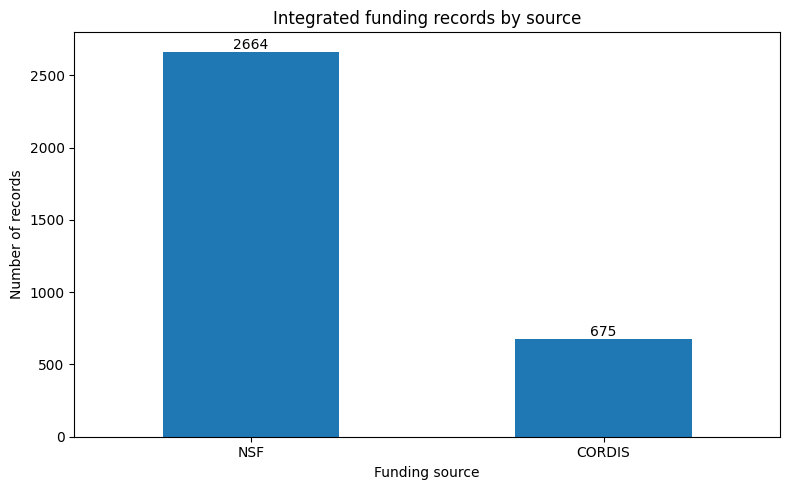

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\01_integrated_funding_records_by_source.png


In [6]:
# Summarize the number and share of integrated records by funding source

source_summary_df = (
    grants_df.groupby("source", as_index=False)
    .agg(
        grant_count=("grant_key", "nunique"),
        first_award_year=("award_year", "min"),
        latest_award_year=("award_year", "max"),
    )
)

source_summary_df["share_of_records_pct"] = (
    source_summary_df["grant_count"]
    / source_summary_df["grant_count"].sum()
    * 100
).round(1)

source_summary_df = source_summary_df.sort_values(
    "grant_count",
    ascending=False,
).reset_index(drop=True)

display(source_summary_df)

# Visualize the contribution of each source
# Visualize the contribution of each source
fig, ax = plt.subplots(figsize=(8, 5))

source_summary_df.plot(
    x="source",
    y="grant_count",
    kind="bar",
    legend=False,
    ax=ax,
)

ax.set_title("Integrated funding records by source")
ax.set_xlabel("Funding source")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

fig.tight_layout()

# Save the specific figure object before displaying it
figure_path = (
    VISUALIZATIONS_DIR
    / "01_integrated_funding_records_by_source.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {figure_path.resolve()}")

source,CORDIS,NSF
award_year,,
2021,0,461
2022,109,479
2023,164,571
2024,212,533
2025,190,620


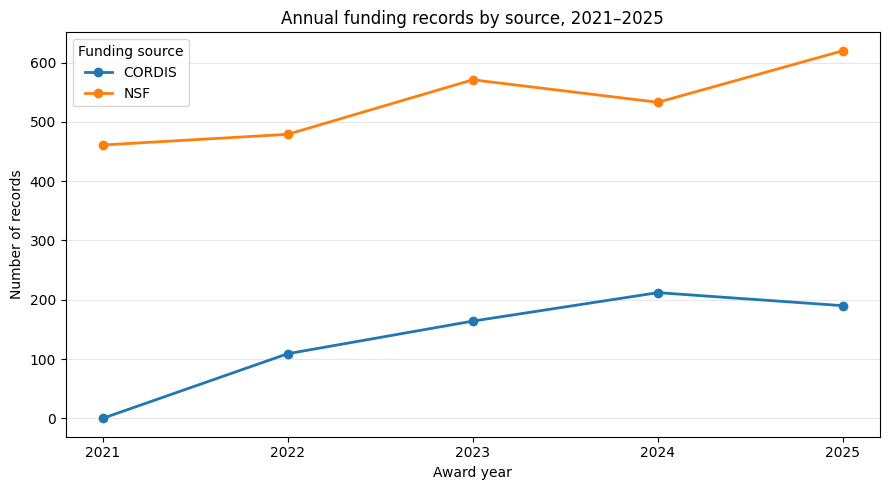

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\02_annual_funding_records_by_source.png


In [7]:
# Summarize annual grant activity by funding source

annual_source_summary_df = (
    grants_df.groupby(
        ["award_year", "source"],
        as_index=False,
    )
    .agg(
        grant_count=("grant_key", "nunique"),
    )
    .sort_values(["award_year", "source"])
)

# Create a table with one column per source
annual_source_pivot_df = (
    annual_source_summary_df.pivot(
        index="award_year",
        columns="source",
        values="grant_count",
    )
    .fillna(0)
    .astype(int)
)

display(annual_source_pivot_df)

# Plot annual activity
fig, ax = plt.subplots(figsize=(9, 5))

for source in annual_source_pivot_df.columns:
    ax.plot(
        annual_source_pivot_df.index,
        annual_source_pivot_df[source],
        marker="o",
        linewidth=2,
        label=source,
    )

ax.set_title("Annual funding records by source, 2021–2025")
ax.set_xlabel("Award year")
ax.set_ylabel("Number of records")
ax.set_xticks(annual_source_pivot_df.index)
ax.legend(title="Funding source")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

figure_path = (
    VISUALIZATIONS_DIR
    / "02_annual_funding_records_by_source.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {figure_path.resolve()}")

### Interpretation: annual activity by funding source

NSF contributes the majority of integrated funding records throughout the 2021–2025 period.

Key observations:

- NSF activity increases overall from 2021 to 2025, despite a temporary decline in 2024.
- The highest NSF record count occurs in 2025.
- The selected CORDIS candidate dataset contains no qualifying 2021 projects and begins contributing records in 2022.
- CORDIS activity increases from 2022 through 2024 before declining slightly in 2025.
- The difference in source volume means that combined grant counts are strongly influenced by NSF.

The absence of CORDIS records in 2021 should not be interpreted as an absence of European research funding. It reflects the date and relevance filters applied to the GrantScopeAI candidate dataset.

Because NSF and CORDIS were collected and filtered using source-specific methods, the chart is best interpreted as activity within the final analytical dataset rather than as a complete comparison of all US and European research funding.

,primary_topic,grant_count,share_of_grants_pct
0,Other AI-enabled chemistry/materials,1100,32.9
1,AI-enabled materials,913,27.3
2,AI-enabled chemistry,803,24.0
3,AI-enabled catalysis,343,10.3
4,Materials informatics,122,3.7
5,Cheminformatics,23,0.7
6,Autonomous laboratories,14,0.4
7,Reaction prediction,12,0.4
8,Molecular machine learning,9,0.3


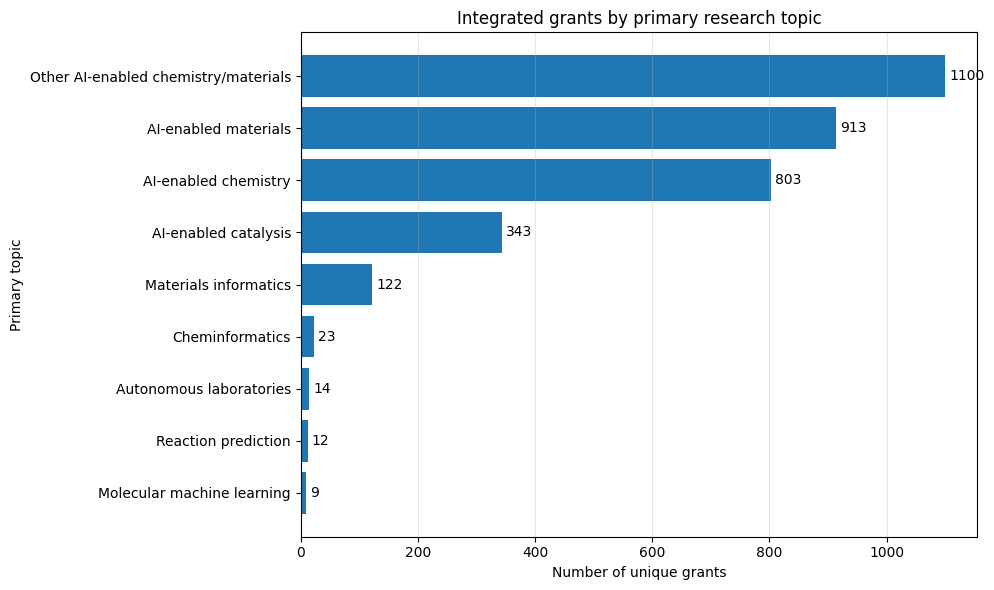

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\03_integrated_grants_by_primary_topic.png


In [8]:
# Summarize unique grants by primary research topic

primary_topic_summary_df = (
    grants_df.groupby("primary_topic", as_index=False)
    .agg(
        grant_count=("grant_key", "nunique"),
    )
)

primary_topic_summary_df["share_of_grants_pct"] = (
    primary_topic_summary_df["grant_count"]
    / primary_topic_summary_df["grant_count"].sum()
    * 100
).round(1)

primary_topic_summary_df = primary_topic_summary_df.sort_values(
    "grant_count",
    ascending=False,
).reset_index(drop=True)

display(primary_topic_summary_df)

# Plot primary-topic distribution
plot_df = primary_topic_summary_df.sort_values(
    "grant_count",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_df["primary_topic"],
    plot_df["grant_count"],
)

ax.set_title("Integrated grants by primary research topic")
ax.set_xlabel("Number of unique grants")
ax.set_ylabel("Primary topic")
ax.grid(axis="x", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
    )

fig.tight_layout()

figure_path = (
    VISUALIZATIONS_DIR
    / "03_integrated_grants_by_primary_topic.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {figure_path.resolve()}")

### Interpretation: primary-topic distribution

The integrated funding landscape is concentrated in broad AI-enabled chemistry and materials categories.

Key observations:

- `Other AI-enabled chemistry/materials` is the largest category, with 1,100 grants, or approximately 32.9% of the integrated dataset.
- `AI-enabled materials` contains 913 grants, approximately 27.3%.
- `AI-enabled chemistry` contains 803 grants, approximately 24.0%.
- `AI-enabled catalysis` is the largest specialised topic, with 343 grants, approximately 10.3%.
- Materials informatics contains 122 grants, while cheminformatics, autonomous laboratories, reaction prediction, and molecular machine learning each contain fewer than 25 primary-topic grants.

Together, the fallback category and the two broad umbrella topics account for approximately 84% of all integrated grants. This indicates that most funded projects use broad chemistry or materials language rather than the narrower terminology associated with specialised AI research fields.

The low primary-topic counts for specialised categories should not be interpreted as evidence that those topics are absent from the funding landscape. A grant receives only one primary topic, based on the taxonomy priority order, even when it matches several topics. Later bridge-based analysis will examine all valid grant-topic relationships and may reveal greater activity within these specialised areas.

For the final dashboard, the fallback category should either be displayed separately or excluded through a filter so that it does not dominate comparisons among the eight named research topics.

relevance_tier,broad_match,core_match,total_grants
primary_topic,,,
Molecular machine learning,4,5,9
Reaction prediction,1,11,12
Autonomous laboratories,4,10,14
Cheminformatics,5,18,23
Materials informatics,12,110,122
AI-enabled catalysis,22,321,343
AI-enabled chemistry,124,679,803
AI-enabled materials,140,773,913
Other AI-enabled chemistry/materials,854,246,1100


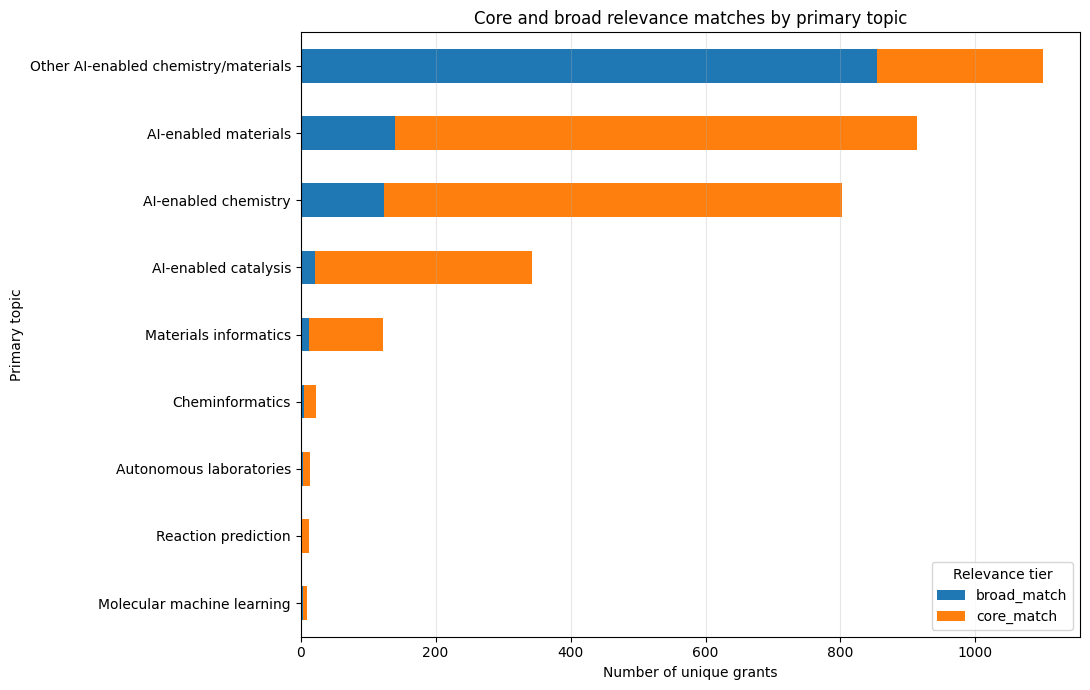

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\04_core_and_broad_matches_by_primary_topic.png


In [9]:
# Compare core and broad relevance classifications by primary topic

topic_relevance_summary_df = (
    grants_df.groupby(
        ["primary_topic", "relevance_tier"],
        as_index=False,
    )
    .agg(
        grant_count=("grant_key", "nunique"),
    )
)

# Reshape the data so relevance tiers become separate columns
topic_relevance_pivot_df = (
    topic_relevance_summary_df.pivot(
        index="primary_topic",
        columns="relevance_tier",
        values="grant_count",
    )
    .fillna(0)
    .astype(int)
)

# Order topics by their total number of grants
topic_relevance_pivot_df["total_grants"] = (
    topic_relevance_pivot_df.sum(axis=1)
)

topic_relevance_pivot_df = topic_relevance_pivot_df.sort_values(
    "total_grants",
    ascending=True,
)

display(topic_relevance_pivot_df)

# Exclude the helper total column from the stacked chart
plot_columns = [
    column
    for column in topic_relevance_pivot_df.columns
    if column != "total_grants"
]

fig, ax = plt.subplots(figsize=(11, 7))

topic_relevance_pivot_df[plot_columns].plot(
    kind="barh",
    stacked=True,
    ax=ax,
)

ax.set_title("Core and broad relevance matches by primary topic")
ax.set_xlabel("Number of unique grants")
ax.set_ylabel("Primary topic")
ax.legend(
    title="Relevance tier",
    loc="lower right",
)
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()

figure_path = (
    VISUALIZATIONS_DIR
    / "04_core_and_broad_matches_by_primary_topic.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {figure_path.resolve()}")

### Interpretation: core and broad relevance by topic

The relevance-tier comparison shows that the named research topics are supported primarily by core matches.

Key observations:

- `Other AI-enabled chemistry/materials` is the only category dominated by broad matches.
- Most grants assigned to `AI-enabled materials` and `AI-enabled chemistry` are core matches, although both categories retain a smaller broad-match component.
- `AI-enabled catalysis` is overwhelmingly composed of core matches.
- The specialised topics—materials informatics, cheminformatics, autonomous laboratories, reaction prediction, and molecular machine learning—are also dominated by core matches.
- Broad matches contribute mainly to the fallback category rather than inflating the specialised topic counts.

This result supports the validity of the named-topic analysis. The eight named categories generally represent records containing strong evidence of both AI-related and chemistry or materials terminology.

The fallback category remains analytically useful, but it should be clearly separated from named-topic comparisons because it contains a substantially larger proportion of lower-confidence broad matches.

,source,primary_topic,grant_count,source_share_pct
6,CORDIS,Other AI-enabled chemistry/materials,334,49.5
1,CORDIS,AI-enabled chemistry,138,20.4
2,CORDIS,AI-enabled materials,118,17.5
0,CORDIS,AI-enabled catalysis,70,10.4
4,CORDIS,Cheminformatics,9,1.3
7,CORDIS,Reaction prediction,3,0.4
5,CORDIS,Materials informatics,2,0.3
3,CORDIS,Autonomous laboratories,1,0.1
10,NSF,AI-enabled materials,795,29.8
15,NSF,Other AI-enabled chemistry/materials,766,28.8


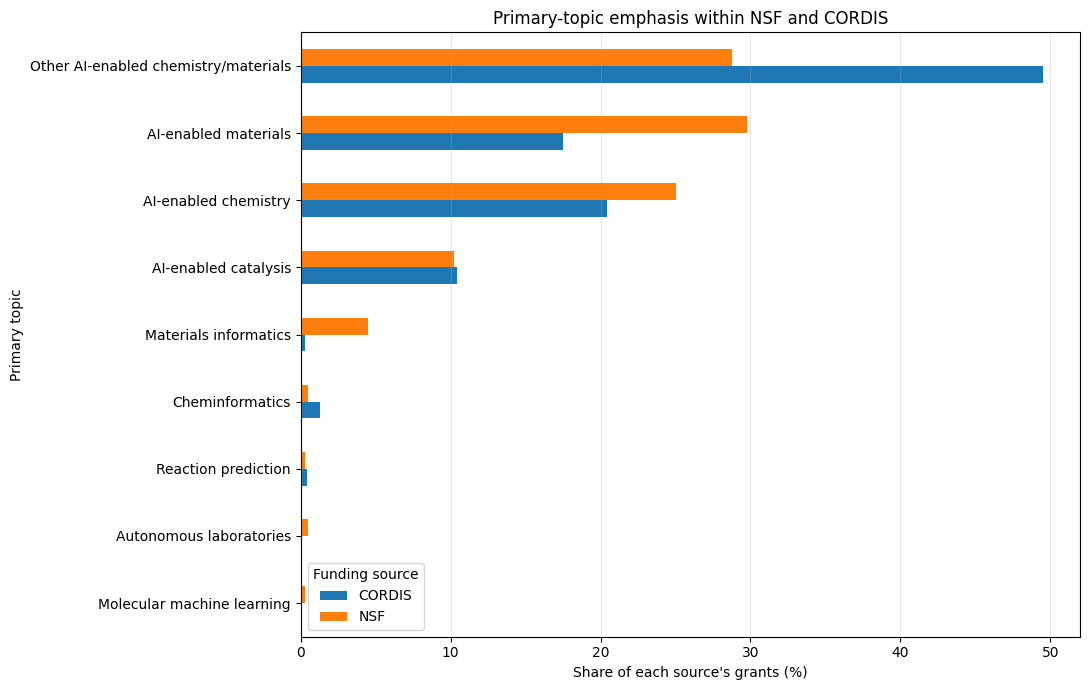

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\05_primary_topic_emphasis_by_source.png


In [10]:
# Compare NSF and CORDIS primary-topic emphasis

source_topic_summary_df = (
    grants_df.groupby(
        ["source", "primary_topic"],
        as_index=False,
    )
    .agg(
        grant_count=("grant_key", "nunique"),
    )
)

# Calculate each topic's percentage within its own funding source
source_totals = (
    source_topic_summary_df.groupby("source")["grant_count"]
    .transform("sum")
)

source_topic_summary_df["source_share_pct"] = (
    source_topic_summary_df["grant_count"]
    / source_totals
    * 100
).round(1)

# Create a percentage table with one column per source
source_topic_pivot_df = (
    source_topic_summary_df.pivot(
        index="primary_topic",
        columns="source",
        values="source_share_pct",
    )
    .fillna(0)
)

# Order topics by their combined percentage across both sources
source_topic_pivot_df["combined_share"] = (
    source_topic_pivot_df.sum(axis=1)
)

source_topic_pivot_df = source_topic_pivot_df.sort_values(
    "combined_share",
    ascending=True,
)

display(
    source_topic_summary_df.sort_values(
        ["source", "source_share_pct"],
        ascending=[True, False],
    )
)

# Exclude the helper column from the chart
plot_columns = [
    column
    for column in source_topic_pivot_df.columns
    if column != "combined_share"
]

fig, ax = plt.subplots(figsize=(11, 7))

source_topic_pivot_df[plot_columns].plot(
    kind="barh",
    ax=ax,
)

ax.set_title("Primary-topic emphasis within NSF and CORDIS")
ax.set_xlabel("Share of each source's grants (%)")
ax.set_ylabel("Primary topic")
ax.legend(title="Funding source")
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()

figure_path = (
    VISUALIZATIONS_DIR
    / "05_primary_topic_emphasis_by_source.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {figure_path.resolve()}")

### Interpretation: NSF and CORDIS topic emphasis

NSF and CORDIS show different topic distributions after adjusting for their unequal dataset sizes.

Key observations:

- Nearly half of the CORDIS candidate records fall under `Other AI-enabled chemistry/materials`, compared with less than one-third of NSF records.
- NSF places a substantially larger share of its records in `AI-enabled materials`.
- NSF also has a somewhat larger share in `AI-enabled chemistry`.
- `AI-enabled catalysis` represents a similar proportion of both funding sources, at approximately one-tenth of each dataset.
- `Materials informatics` is much more prominent within NSF than within CORDIS.
- CORDIS has a slightly larger relative presence in `Cheminformatics`, although the category remains small in both sources.
- Autonomous laboratories, reaction prediction, and molecular machine learning account for only small shares of either source.

The larger CORDIS fallback share may reflect differences in programme language and project descriptions rather than a true absence of specialised AI research. European projects may describe broader consortium goals, industrial applications, or enabling technologies without using the exact terminology required by the named-topic rules.

For the final dashboard, percentages should be used when comparing source emphasis because raw counts would be dominated by the larger NSF dataset.

,source,currency,award_count,values_available,minimum_amount,first_quartile,median_amount,mean_amount,third_quartile,maximum_amount
0,CORDIS,EUR,675,675,75000.0,1006872.0,2495850.0,3429062.0,4873775.0,37995202.0
1,NSF,USD,2664,2664,5000.0,289934.0,452796.0,1167944.0,666750.0,195500000.0


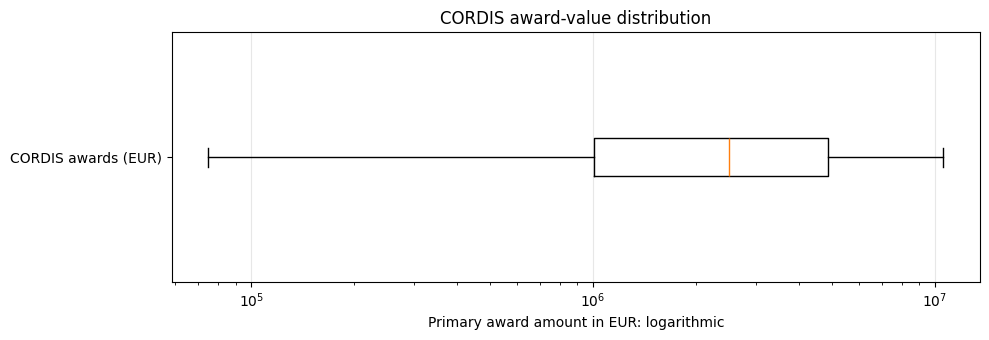

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\06_cordis_award_value_distribution_eur.png


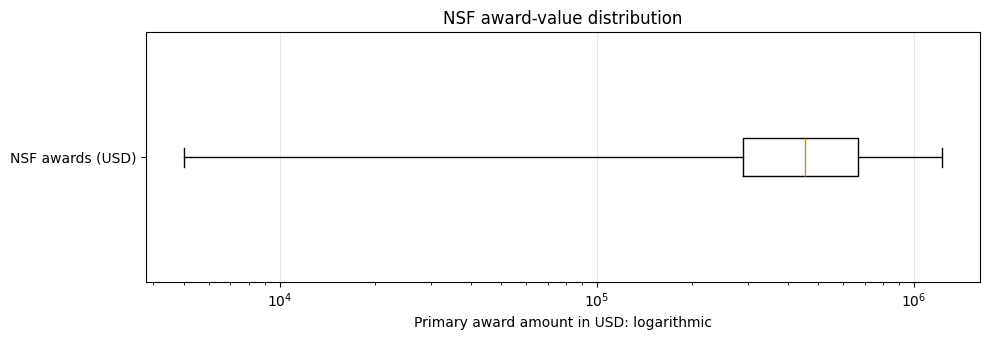

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\07_nsf_award_value_distribution_usd.png


In [12]:
# Summarize and visualize award-value distributions separately by source

grants_df["amount_native"] = pd.to_numeric(
    grants_df["amount_native"],
    errors="coerce",
)

# Create source-specific descriptive statistics
award_value_summary_df = (
    grants_df.groupby(
        ["source", "currency"],
        as_index=False,
    )
    .agg(
        award_count=("grant_key", "nunique"),
        values_available=("amount_native", "count"),
        minimum_amount=("amount_native", "min"),
        first_quartile=(
            "amount_native",
            lambda values: values.quantile(0.25),
        ),
        median_amount=("amount_native", "median"),
        mean_amount=("amount_native", "mean"),
        third_quartile=(
            "amount_native",
            lambda values: values.quantile(0.75),
        ),
        maximum_amount=("amount_native", "max"),
    )
)

amount_columns = [
    "minimum_amount",
    "first_quartile",
    "median_amount",
    "mean_amount",
    "third_quartile",
    "maximum_amount",
]

award_value_summary_df[amount_columns] = (
    award_value_summary_df[amount_columns].round(0)
)

display(award_value_summary_df)

# Keep EUR and USD in separate plots
source_figure_settings = {
    "CORDIS": {
        "currency": "EUR",
        "filename": "06_cordis_award_value_distribution_eur.png",
    },
    "NSF": {
        "currency": "USD",
        "filename": "07_nsf_award_value_distribution_usd.png",
    },
}

for source, settings in source_figure_settings.items():

    source_values = (
        grants_df.loc[
            (grants_df["source"] == source)
            & (grants_df["amount_native"] > 0),
            "amount_native",
        ]
        .dropna()
    )

    fig, ax = plt.subplots(figsize=(10, 3.5))

    ax.boxplot(
        source_values,
        vert=False,
        showfliers=False,
    )

    ax.set_xscale("log")
    ax.set_yticks([1])
    ax.set_yticklabels(
        [f"{source} awards ({settings['currency']})"]
    )

    ax.set_title(f"{source} award-value distribution")
    ax.set_xlabel(
        f"Primary award amount in "
        f"{settings['currency']}: logarithmic"
    )
    ax.grid(axis="x", alpha=0.3)

    fig.tight_layout()

    figure_path = (
        VISUALIZATIONS_DIR
        / settings["filename"]
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Figure saved to: {figure_path.resolve()}")

### Interpretation: award-value distributions by source

Award values differ substantially between NSF and CORDIS, both in scale and distribution.

Key observations:

- CORDIS projects have a median maximum EU contribution of approximately €2.50 million.
- NSF awards have a median estimated total value of approximately $452,796.
- The mean is higher than the median for both sources, indicating right-skewed distributions influenced by a smaller number of very large awards.
- CORDIS has an interquartile range of approximately €1.01 million to €4.87 million.
- NSF has an interquartile range of approximately $289,934 to $666,750.
- The maximum NSF award is $195.5 million, which is far above the typical award and strongly affects the mean.
- The maximum CORDIS contribution is approximately €38.0 million.

The logarithmic boxplots make the typical award ranges easier to inspect despite the presence of very large awards.

These values should not be interpreted as a direct comparison of funding generosity. NSF and CORDIS report different financial concepts, operate in different currencies, and fund projects through different programme structures.

For later dashboard use, the median and interquartile range will generally provide more representative summaries than the mean.

## 2. Publication momentum by research topic

Funding activity shows where research projects are receiving financial support, while publication activity provides a separate signal of scientific attention and growth.

This section uses the OpenAlex topic-year dataset to examine:

- annual publication counts from 2021 through 2025;
- absolute publication growth;
- percentage growth from the 2021 baseline;
- the 2025 publication index;
- topics with the strongest recent momentum.

Publication growth will be interpreted carefully. A topic with a small starting publication count may show a large percentage increase even when its absolute growth remains modest.

The analysis therefore considers both absolute and percentage change rather than relying on a single growth metric.

,topic,years_available,first_year,latest_year,total_publications
2,AI-enabled materials,5,2021,2025,1187031
1,AI-enabled chemistry,5,2021,2025,446426
0,AI-enabled catalysis,5,2021,2025,98317
4,Cheminformatics,5,2021,2025,19679
5,Materials informatics,5,2021,2025,3573
6,Molecular machine learning,5,2021,2025,2267
7,Reaction prediction,5,2021,2025,2018
3,Autonomous laboratories,5,2021,2025,1766


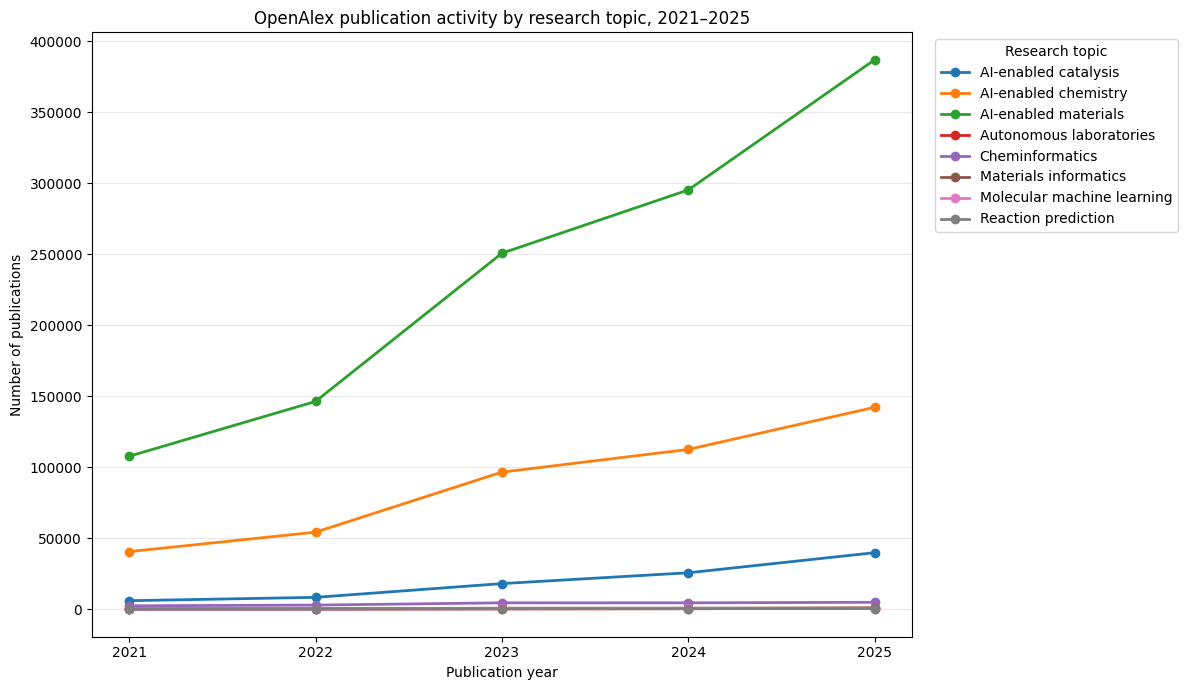

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\08_openalex_publication_activity_by_topic.png


In [13]:
# Summarize annual OpenAlex publication activity by research topic

publication_trend_df = (
    topic_year_context_df[
        ["topic", "year", "publication_count"]
    ]
    .copy()
)

publication_trend_df["year"] = pd.to_numeric(
    publication_trend_df["year"],
    errors="coerce",
).astype("Int64")

publication_trend_df["publication_count"] = pd.to_numeric(
    publication_trend_df["publication_count"],
    errors="coerce",
)

publication_trend_df = publication_trend_df.sort_values(
    ["topic", "year"]
)

# Confirm that every topic has five annual observations
publication_coverage_df = (
    publication_trend_df.groupby("topic", as_index=False)
    .agg(
        years_available=("year", "nunique"),
        first_year=("year", "min"),
        latest_year=("year", "max"),
        total_publications=("publication_count", "sum"),
    )
    .sort_values(
        "total_publications",
        ascending=False,
    )
)

display(publication_coverage_df)

# Reshape for plotting
publication_trend_pivot_df = (
    publication_trend_df.pivot(
        index="year",
        columns="topic",
        values="publication_count",
    )
    .sort_index()
)

# Plot annual publication activity
fig, ax = plt.subplots(figsize=(12, 7))

for topic in publication_trend_pivot_df.columns:
    ax.plot(
        publication_trend_pivot_df.index,
        publication_trend_pivot_df[topic],
        marker="o",
        linewidth=2,
        label=topic,
    )

ax.set_title(
    "OpenAlex publication activity by research topic, 2021–2025"
)
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of publications")
ax.set_xticks(publication_trend_pivot_df.index)
ax.grid(axis="y", alpha=0.3)

ax.legend(
    title="Research topic",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.tight_layout()

figure_path = (
    VISUALIZATIONS_DIR
    / "08_openalex_publication_activity_by_topic.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {figure_path.resolve()}")

### Interpretation: absolute publication activity

OpenAlex publication activity increases across all eight research topics between 2021 and 2025, but the absolute scale differs substantially.

Key observations:

- `AI-enabled materials` is the largest publication category in every year and grows from approximately 108,000 publications in 2021 to almost 390,000 in 2025.
- `AI-enabled chemistry` is the second-largest category and also shows substantial growth.
- `AI-enabled catalysis` is the largest specialised topic by absolute publication volume.
- The remaining specialised topics have much smaller publication counts and are difficult to distinguish on the shared linear scale.
- The broad topic searches produce much larger result volumes than the narrower scientific categories.

This chart is useful for understanding the total size of each publication landscape, but it is not sufficient for comparing relative momentum. Large topics dominate the vertical scale, while smaller topics may still be growing rapidly from a lower baseline.

The next analysis will therefore index every topic to its 2021 publication level. This will allow relative growth to be compared without confusing publication volume with publication momentum.

,topic,publication_count_2021,publication_count_2025,publication_index_2021,absolute_growth_2021_2025,growth_2021_2025_pct
0,Autonomous laboratories,75,859,1145.333333,784,1045.3
1,AI-enabled catalysis,6094,39893,654.627502,33799,554.6
2,AI-enabled materials,107790,386893,358.932183,279103,258.9
3,AI-enabled chemistry,40651,142246,349.920051,101595,249.9
4,Reaction prediction,197,576,292.385787,379,192.4
5,Molecular machine learning,189,549,290.476190,360,190.5
6,Materials informatics,398,1021,256.532663,623,156.5
7,Cheminformatics,2511,4975,198.128236,2464,98.1


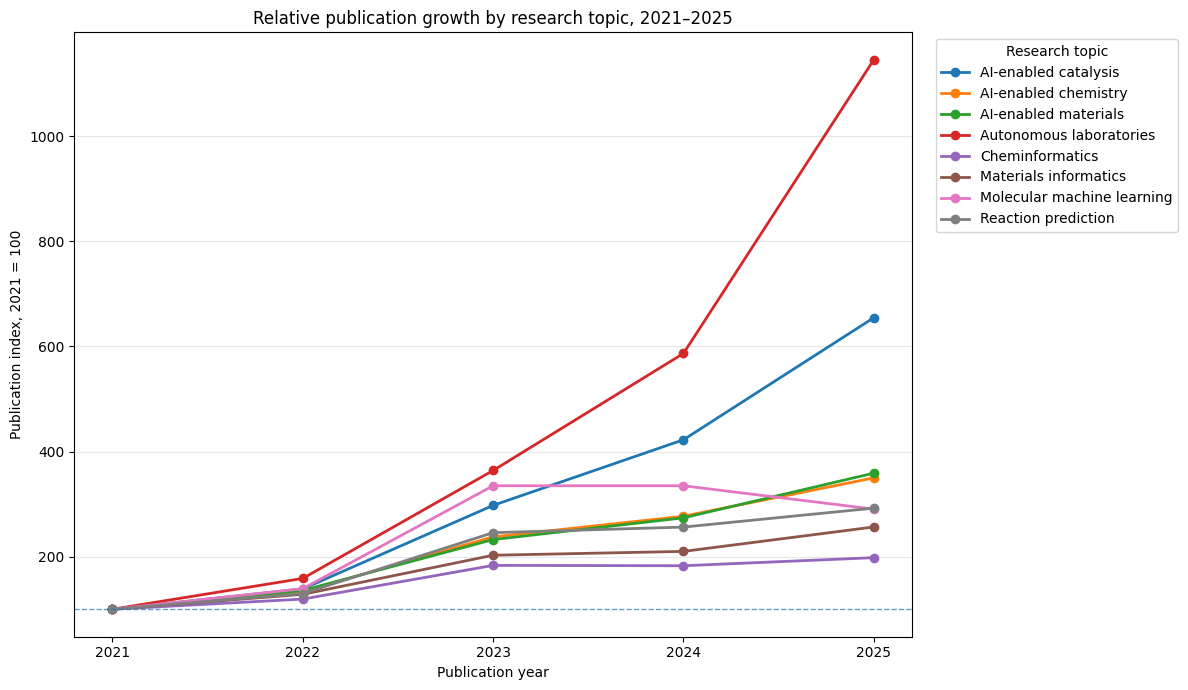

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\09_relative_publication_growth_by_topic.png


In [14]:
# Compare relative publication growth using 2021 as the baseline

publication_index_df = publication_trend_df.copy()

# Add the 2021 publication count for each topic
baseline_publications_df = (
    publication_index_df.loc[
        publication_index_df["year"] == 2021,
        ["topic", "publication_count"],
    ]
    .rename(
        columns={
            "publication_count": "publication_count_2021"
        }
    )
)

publication_index_df = publication_index_df.merge(
    baseline_publications_df,
    on="topic",
    how="left",
    validate="many_to_one",
)

# Calculate an index where 2021 equals 100
publication_index_df["publication_index_2021"] = (
    publication_index_df["publication_count"]
    / publication_index_df["publication_count_2021"]
    * 100
)

# Create a 2025 relative-growth summary
publication_growth_2025_df = (
    publication_index_df.loc[
        publication_index_df["year"] == 2025,
        [
            "topic",
            "publication_count_2021",
            "publication_count",
            "publication_index_2021",
        ],
    ]
    .rename(
        columns={
            "publication_count": "publication_count_2025"
        }
    )
)

publication_growth_2025_df["absolute_growth_2021_2025"] = (
    publication_growth_2025_df["publication_count_2025"]
    - publication_growth_2025_df["publication_count_2021"]
)

publication_growth_2025_df["growth_2021_2025_pct"] = (
    publication_growth_2025_df["publication_index_2021"] - 100
).round(1)

publication_growth_2025_df = (
    publication_growth_2025_df.sort_values(
        "growth_2021_2025_pct",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(publication_growth_2025_df)

# Reshape the index values for plotting
publication_index_pivot_df = (
    publication_index_df.pivot(
        index="year",
        columns="topic",
        values="publication_index_2021",
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 7))

for topic in publication_index_pivot_df.columns:
    ax.plot(
        publication_index_pivot_df.index,
        publication_index_pivot_df[topic],
        marker="o",
        linewidth=2,
        label=topic,
    )

ax.axhline(
    100,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.set_title(
    "Relative publication growth by research topic, 2021–2025"
)
ax.set_xlabel("Publication year")
ax.set_ylabel("Publication index, 2021 = 100")
ax.set_xticks(publication_index_pivot_df.index)
ax.grid(axis="y", alpha=0.3)

ax.legend(
    title="Research topic",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.tight_layout()

figure_path = (
    VISUALIZATIONS_DIR
    / "09_relative_publication_growth_by_topic.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {figure_path.resolve()}")

### Interpretation: relative publication momentum

Indexing each topic to its 2021 publication level reveals major differences in relative research momentum that were hidden in the absolute publication-count chart.

Key observations:

- `Autonomous laboratories` shows the strongest relative growth, increasing to more than eleven times its 2021 publication level by 2025.
- `AI-enabled catalysis` shows the second-strongest relative momentum, reaching more than six times its 2021 level.
- `AI-enabled chemistry` and `AI-enabled materials` both show sustained growth and reach approximately three-and-a-half times their 2021 publication levels.
- `Reaction prediction` and `Materials informatics` grow steadily but less dramatically.
- `Cheminformatics` shows the slowest relative growth among the selected topics.
- `Molecular machine learning` grows rapidly through 2023, remains relatively stable in 2024, and then declines in 2025 while still remaining well above its 2021 baseline.

The exceptionally high growth of autonomous laboratories should be interpreted alongside its absolute publication count. A smaller starting value can produce a very large percentage increase, so relative momentum does not necessarily mean that the topic has the largest research community.

This result provides a promising strategic signal for GrantScopeAI: autonomous laboratories and AI-enabled catalysis appear to be rapidly emerging areas, while the broader chemistry and materials categories remain much larger in absolute volume.

The final dashboard should present both absolute publication volume and indexed growth so users can distinguish between established scale and emerging momentum.

## 3. Connecting publication momentum with funding activity

The next stage combines the funding and publication perspectives at the shared topic-year level.

OpenAlex publication records will not be merged into individual NSF or CORDIS grants. The datasets do not contain reliable identifiers connecting a publication directly to a specific award.

Instead, the analysis will compare:

- annual unique-grant activity by primary topic;
- annual OpenAlex publication activity;
- recent publication growth;
- recent grant volume;
- differences between scientific momentum and observed funding activity.

Only the eight named research topics will be included. The fallback category is excluded because it has no equivalent OpenAlex topic.

Combined funding trends will use 2022 as the starting year because the final CORDIS candidate dataset contains no qualifying 2021 records. Using 2021 as the combined funding baseline would create an artificial growth effect.

The purpose is not to prove that a topic is underfunded or that publication growth causes funding growth. The analysis is intended to identify strategic patterns that users may investigate further.

Topic-year rows: 32
Topics: 8
Years: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,topic,year,grant_count
0,AI-enabled catalysis,2022,63
1,AI-enabled catalysis,2023,80
2,AI-enabled catalysis,2024,72
3,AI-enabled catalysis,2025,88
4,AI-enabled chemistry,2022,153
5,AI-enabled chemistry,2023,158
6,AI-enabled chemistry,2024,181
7,AI-enabled chemistry,2025,207
8,AI-enabled materials,2022,152
9,AI-enabled materials,2023,209


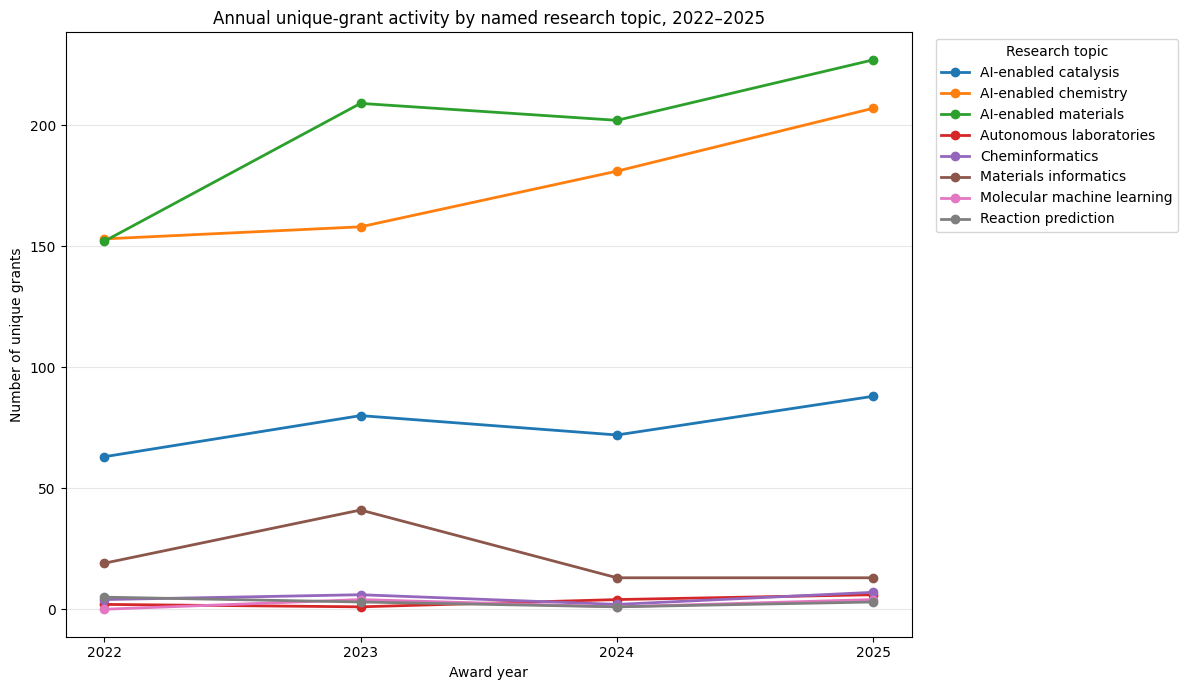

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\10_annual_named_topic_grant_activity.png


In [15]:
# Calculate annual unique-grant activity for the eight named topics

# Derive the shared named-topic list from the OpenAlex context table
named_topics = sorted(
    topic_year_context_df["topic"]
    .dropna()
    .unique()
)

comparison_years = list(range(2022, 2026))

# Count each grant once using its primary topic
named_topic_grants_df = grants_df.loc[
    grants_df["primary_topic"].isin(named_topics)
    & grants_df["award_year"].isin(comparison_years)
].copy()

annual_topic_grants_df = (
    named_topic_grants_df.groupby(
        ["primary_topic", "award_year"],
        as_index=False,
    )
    .agg(
        grant_count=("grant_key", "nunique"),
    )
    .rename(
        columns={
            "primary_topic": "topic",
            "award_year": "year",
        }
    )
)

# Create the complete eight-topic by four-year grid
topic_year_grid_df = pd.MultiIndex.from_product(
    [named_topics, comparison_years],
    names=["topic", "year"],
).to_frame(index=False)

annual_topic_grants_complete_df = (
    topic_year_grid_df.merge(
        annual_topic_grants_df,
        on=["topic", "year"],
        how="left",
        validate="one_to_one",
    )
)

annual_topic_grants_complete_df["grant_count"] = (
    annual_topic_grants_complete_df["grant_count"]
    .fillna(0)
    .astype(int)
)

# Validate the expected structure
print(
    "Topic-year rows:",
    len(annual_topic_grants_complete_df),
)
print(
    "Topics:",
    annual_topic_grants_complete_df["topic"].nunique(),
)
print(
    "Years:",
    sorted(annual_topic_grants_complete_df["year"].unique()),
)

display(
    annual_topic_grants_complete_df.sort_values(
        ["topic", "year"]
    )
)

# Reshape for plotting
annual_topic_grants_pivot_df = (
    annual_topic_grants_complete_df.pivot(
        index="year",
        columns="topic",
        values="grant_count",
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 7))

for topic in annual_topic_grants_pivot_df.columns:
    ax.plot(
        annual_topic_grants_pivot_df.index,
        annual_topic_grants_pivot_df[topic],
        marker="o",
        linewidth=2,
        label=topic,
    )

ax.set_title(
    "Annual unique-grant activity by named research topic, 2022–2025"
)
ax.set_xlabel("Award year")
ax.set_ylabel("Number of unique grants")
ax.set_xticks(comparison_years)
ax.grid(axis="y", alpha=0.3)

ax.legend(
    title="Research topic",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.tight_layout()

figure_path = (
    VISUALIZATIONS_DIR
    / "10_annual_named_topic_grant_activity.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {figure_path.resolve()}")

### Interpretation: annual grant activity by named topic

Grant activity is concentrated in the three largest named research categories, while the narrower specialised topics contain relatively few awards.

Key observations:

- `AI-enabled materials` has the highest grant activity throughout most of the 2022–2025 period and reaches its largest annual count in 2025.
- `AI-enabled chemistry` also grows overall, increasing more steadily across the four years.
- `AI-enabled catalysis` is the largest specialised topic and shows moderate growth despite a decline in 2024.
- `Materials informatics` rises sharply in 2023 but then falls substantially in 2024 and remains lower in 2025.
- Autonomous laboratories, reaction prediction, cheminformatics, and molecular machine learning remain small in absolute grant volume.
- Several specialised topics show only a few primary-topic grants per year, so small changes can produce large percentage-growth values.

The funding trends are less dramatic than the OpenAlex publication trends. For example, autonomous laboratories shows exceptionally strong publication growth but remains a small funding category in the integrated grant dataset.

This difference should be treated as a research-intelligence signal rather than evidence that a topic is definitively underfunded. Grant counts are influenced by the topic-classification rules, source coverage, programme terminology, and the use of one primary topic per grant.

The next comparison will calculate consistent 2022–2025 grant-growth indicators and align them with OpenAlex publication momentum.

year,topic,grant_count_2022,grant_count_2025,publication_count_2022,publication_count_2025,grant_change_2022_2025,publication_change_2022_2025,grant_growth_2022_2025_pct,publication_growth_2022_2025_pct
0,Autonomous laboratories,2,6,119,859,4,740,200.0,621.8
1,AI-enabled catalysis,63,88,8449,39893,25,31444,39.7,372.2
2,AI-enabled materials,152,227,146376,386893,75,240517,49.3,164.3
3,AI-enabled chemistry,153,207,54337,142246,54,87909,35.3,161.8
4,Reaction prediction,5,3,256,576,-2,320,-40.0,125.0
5,Molecular machine learning,0,4,263,549,4,286,NaN,108.7
6,Materials informatics,19,13,511,1021,-6,510,-31.6,99.8
7,Cheminformatics,4,7,2997,4975,3,1978,75.0,66.0


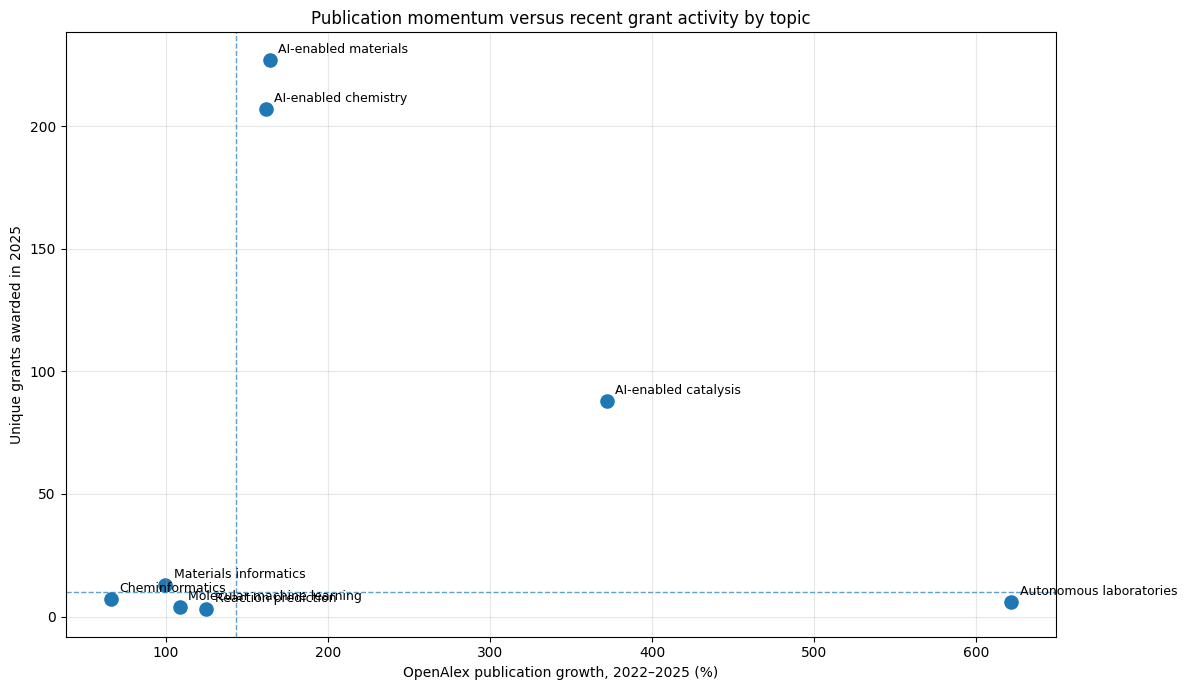

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\11_publication_momentum_vs_grant_activity.png
Topics with undefined grant-growth percentages because their 2022 baseline was zero: ['Molecular machine learning']


In [16]:
# Build a one-row-per-topic funding and publication comparison

comparison_start_year = 2022
comparison_end_year = 2025

# Reshape annual grant counts so the start and end years become columns
grant_change_df = (
    annual_topic_grants_complete_df.loc[
        annual_topic_grants_complete_df["year"].isin(
            [comparison_start_year, comparison_end_year]
        )
    ]
    .pivot(
        index="topic",
        columns="year",
        values="grant_count",
    )
    .reset_index()
    .rename(
        columns={
            comparison_start_year: "grant_count_2022",
            comparison_end_year: "grant_count_2025",
        }
    )
)

# Reshape publication counts using the same comparison years
publication_change_df = (
    publication_trend_df.loc[
        publication_trend_df["year"].isin(
            [comparison_start_year, comparison_end_year]
        )
    ]
    .pivot(
        index="topic",
        columns="year",
        values="publication_count",
    )
    .reset_index()
    .rename(
        columns={
            comparison_start_year: "publication_count_2022",
            comparison_end_year: "publication_count_2025",
        }
    )
)

# Combine the two topic-level summaries
funding_publication_comparison_df = grant_change_df.merge(
    publication_change_df,
    on="topic",
    how="inner",
    validate="one_to_one",
)

# Calculate absolute changes
funding_publication_comparison_df["grant_change_2022_2025"] = (
    funding_publication_comparison_df["grant_count_2025"]
    - funding_publication_comparison_df["grant_count_2022"]
)

funding_publication_comparison_df[
    "publication_change_2022_2025"
] = (
    funding_publication_comparison_df["publication_count_2025"]
    - funding_publication_comparison_df["publication_count_2022"]
)

# Calculate percentage changes
# Grant growth remains missing when the 2022 baseline equals zero
funding_publication_comparison_df["grant_growth_2022_2025_pct"] = (
    np.where(
        funding_publication_comparison_df["grant_count_2022"] > 0,
        (
            funding_publication_comparison_df["grant_count_2025"]
            / funding_publication_comparison_df["grant_count_2022"]
            - 1
        )
        * 100,
        np.nan,
    )
)

funding_publication_comparison_df[
    "publication_growth_2022_2025_pct"
] = (
    (
        funding_publication_comparison_df["publication_count_2025"]
        / funding_publication_comparison_df["publication_count_2022"]
        - 1
    )
    * 100
)

# Round growth percentages for display
growth_columns = [
    "grant_growth_2022_2025_pct",
    "publication_growth_2022_2025_pct",
]

funding_publication_comparison_df[growth_columns] = (
    funding_publication_comparison_df[growth_columns].round(1)
)

funding_publication_comparison_df = (
    funding_publication_comparison_df.sort_values(
        "publication_growth_2022_2025_pct",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(funding_publication_comparison_df)

# Create the strategic momentum matrix
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    funding_publication_comparison_df[
        "publication_growth_2022_2025_pct"
    ],
    funding_publication_comparison_df["grant_count_2025"],
    s=90,
)

# Add topic labels
for _, row in funding_publication_comparison_df.iterrows():
    ax.annotate(
        row["topic"],
        (
            row["publication_growth_2022_2025_pct"],
            row["grant_count_2025"],
        ),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9,
    )

# Add median reference lines to create four visual quadrants
median_publication_growth = funding_publication_comparison_df[
    "publication_growth_2022_2025_pct"
].median()

median_grant_activity = funding_publication_comparison_df[
    "grant_count_2025"
].median()

ax.axvline(
    median_publication_growth,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.axhline(
    median_grant_activity,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.set_title(
    "Publication momentum versus recent grant activity by topic"
)
ax.set_xlabel("OpenAlex publication growth, 2022–2025 (%)")
ax.set_ylabel("Unique grants awarded in 2025")
ax.grid(alpha=0.3)

fig.tight_layout()

figure_path = (
    VISUALIZATIONS_DIR
    / "11_publication_momentum_vs_grant_activity.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {figure_path.resolve()}")

# Identify topics where grant percentage growth could not be calculated
undefined_grant_growth_topics = (
    funding_publication_comparison_df.loc[
        funding_publication_comparison_df[
            "grant_growth_2022_2025_pct"
        ].isna(),
        "topic",
    ]
    .tolist()
)

print(
    "Topics with undefined grant-growth percentages because "
    f"their 2022 baseline was zero: {undefined_grant_growth_topics}"
)

### Interpretation: publication momentum versus grant activity

The combined comparison reveals several different research-intelligence patterns across the eight topics.

Key observations:

- `Autonomous laboratories` has the strongest publication momentum, growing by approximately 622% between 2022 and 2025. Grant activity also increases, but only from two to six primary-topic grants. This suggests a rapidly emerging research area that remains small in absolute funding volume.
- `AI-enabled catalysis` combines very strong publication growth of approximately 372% with substantial grant activity. Its 88 grants in 2025 make it the strongest specialised topic when both scientific momentum and funding presence are considered.
- `AI-enabled materials` and `AI-enabled chemistry` are the most established areas. Both have high publication volumes, more than 200 grants in 2025, and continued growth in funding activity.
- `Reaction prediction` publication activity increases by 125%, while primary-topic grant activity falls from five grants to three. This may represent a possible funding–publication mismatch, although the small grant counts make the result sensitive to individual records.
- `Materials informatics` publication activity nearly doubles, while grant activity falls from 19 to 13. This is another possible divergence that may warrant closer investigation.
- `Molecular machine learning` has no primary-topic grants in the 2022 baseline, so a grant-growth percentage cannot be calculated reliably. It reaches four grants in 2025 while publication activity more than doubles.
- `Cheminformatics` shows more moderate publication growth of 66% and an increase from four to seven grants.

The strongest presentation-ready finding is that research momentum and observed grant activity do not always move together.

`AI-enabled catalysis` appears to combine both strong publication momentum and meaningful funding activity, while `Autonomous laboratories` shows exceptional scientific growth from a much smaller funding base.

These patterns should be described as strategic signals rather than proof of underfunding. Results are affected by source coverage, keyword classification, small category sizes, and the use of one primary topic per grant.

In [17]:
funding_publication_comparison_df.columns.name = None

## 4. Programme and organisation intelligence

The previous sections identified how funding activity and publication momentum vary across research topics. This section examines the programmes and organisations behind that activity.

The analysis will investigate:

- the most active NSF programmes;
- the most active CORDIS calls and funding mechanisms;
- leading recipient or coordinating organisations;
- programme and organisation activity within each named topic;
- potential organisations and funded projects to feature in the final application demonstration.

NSF and CORDIS programme fields will be analysed separately because they represent different funding structures:

- NSF records describe US programme and directorate classifications;
- CORDIS records describe European call topics and funding mechanisms.

Programme names and award values will therefore not be combined into a single ranking.

Organisation counts represent the lead awardee or project coordinator recorded by each source. They do not represent every collaborator involved in a funded project.

The objective is to identify interpretable programme and institutional patterns that can support the final dashboard and help Streamlit users understand where similar research has previously received support.

,source,currency,programme_name_clean,grant_count,source_share_pct,median_award_amount
0,CORDIS,EUR,MSCA Postdoctoral Fellowships 2023,27,7.9,203464.0
1,CORDIS,EUR,ERC STARTING GRANTS,26,7.6,1499464.0
2,CORDIS,EUR,ERC ADVANCED GRANTS,21,6.2,2499250.0
3,CORDIS,EUR,MSCA Postdoctoral Fellowships 2024,20,5.9,213077.0
4,CORDIS,EUR,ERC CONSOLIDATOR GRANTS,19,5.6,1999073.0
5,CORDIS,EUR,MSCA Postdoctoral Fellowships 2022,15,4.4,196829.0
6,CORDIS,EUR,MSCA Postdoctoral Fellowships 2021,13,3.8,184077.0
7,CORDIS,EUR,ERC PROOF OF CONCEPT GRANTS,10,2.9,150000.0
8,CORDIS,EUR,EIC Pathfinder Open,8,2.3,2977796.0
9,CORDIS,EUR,MSCA Doctoral Networks 2022,7,2.1,2643703.0


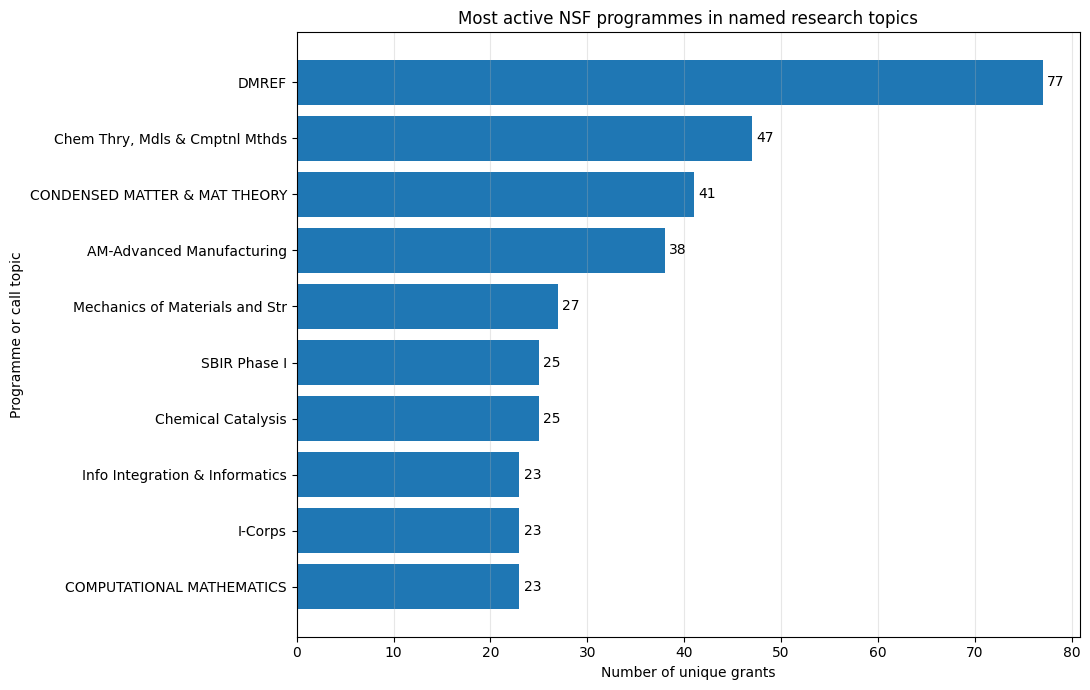

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\12_top_nsf_programmes.png


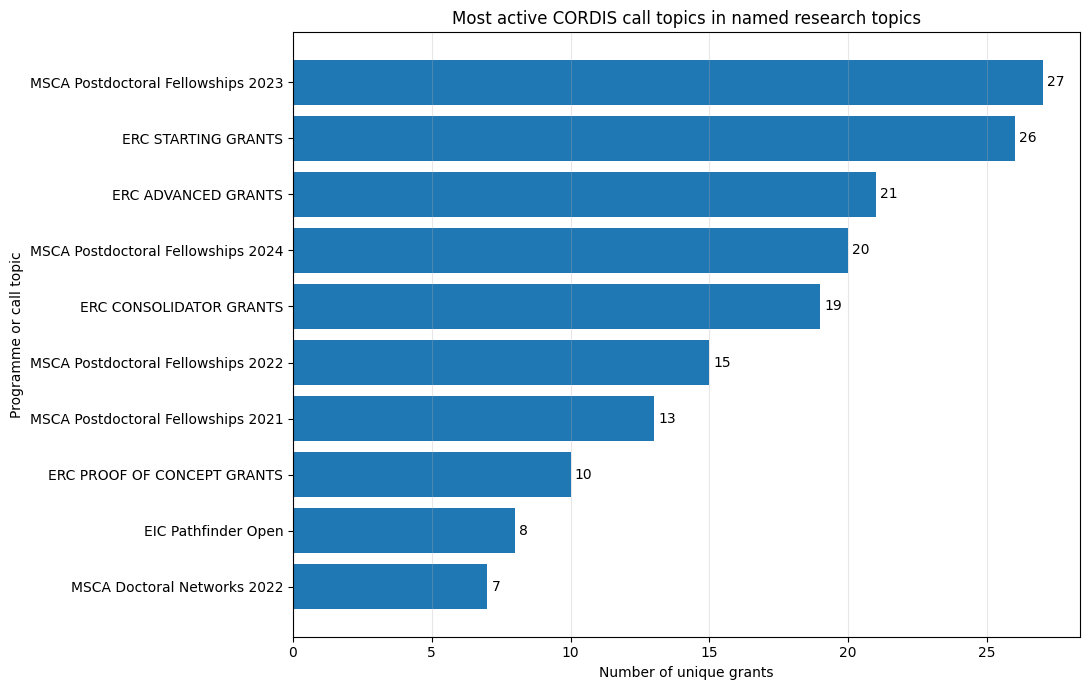

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\13_top_cordis_call_topics.png


In [18]:
# Identify the most active NSF programmes and CORDIS call topics
# within the eight named research topics

named_topic_grants_all_years_df = grants_df.loc[
    grants_df["primary_topic"].isin(named_topics)
].copy()

# Clean programme labels and replace missing values
named_topic_grants_all_years_df["programme_name_clean"] = (
    named_topic_grants_all_years_df["programme_name"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .fillna("Programme not reported")
)

# Create a programme summary separately for each source
programme_summary_df = (
    named_topic_grants_all_years_df.groupby(
        ["source", "currency", "programme_name_clean"],
        as_index=False,
    )
    .agg(
        grant_count=("grant_key", "nunique"),
        median_award_amount=("amount_native", "median"),
        total_award_amount=("amount_native", "sum"),
    )
)

# Calculate each programme's share within its own source
source_named_topic_totals = (
    named_topic_grants_all_years_df.groupby("source")["grant_key"]
    .nunique()
    .rename("source_named_topic_grants")
    .reset_index()
)

programme_summary_df = programme_summary_df.merge(
    source_named_topic_totals,
    on="source",
    how="left",
    validate="many_to_one",
)

programme_summary_df["source_share_pct"] = (
    programme_summary_df["grant_count"]
    / programme_summary_df["source_named_topic_grants"]
    * 100
).round(1)

programme_summary_df["median_award_amount"] = (
    programme_summary_df["median_award_amount"].round(0)
)

programme_summary_df["total_award_amount"] = (
    programme_summary_df["total_award_amount"].round(0)
)

# Select the ten most active programmes for each source
top_programmes_by_source_df = (
    programme_summary_df.sort_values(
        ["source", "grant_count", "programme_name_clean"],
        ascending=[True, False, True],
    )
    .groupby("source", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

display(
    top_programmes_by_source_df[
        [
            "source",
            "currency",
            "programme_name_clean",
            "grant_count",
            "source_share_pct",
            "median_award_amount",
        ]
    ]
)

# Create one separate programme chart for each source
programme_figure_settings = {
    "NSF": {
        "title": "Most active NSF programmes in named research topics",
        "filename": "12_top_nsf_programmes.png",
    },
    "CORDIS": {
        "title": "Most active CORDIS call topics in named research topics",
        "filename": "13_top_cordis_call_topics.png",
    },
}

for source, settings in programme_figure_settings.items():

    source_plot_df = (
        top_programmes_by_source_df.loc[
            top_programmes_by_source_df["source"] == source
        ]
        .sort_values("grant_count", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(11, 7))

    ax.barh(
        source_plot_df["programme_name_clean"],
        source_plot_df["grant_count"],
    )

    ax.set_title(settings["title"])
    ax.set_xlabel("Number of unique grants")
    ax.set_ylabel("Programme or call topic")
    ax.grid(axis="x", alpha=0.3)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.0f",
            padding=3,
        )

    fig.tight_layout()

    figure_path = (
        VISUALIZATIONS_DIR
        / settings["filename"]
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Figure saved to: {figure_path.resolve()}")
    

### Interpretation: programme activity by funding source

The programme analysis shows that NSF and CORDIS support AI-enabled chemistry and materials research through different funding structures.

Key observations:

- CORDIS activity is strongly represented by researcher-focused schemes, particularly Marie Skłodowska-Curie Actions and European Research Council grants.
- MSCA Postdoctoral Fellowship calls appear repeatedly across different years, indicating sustained support for individual researcher mobility and development.
- ERC Starting, Consolidator, and Advanced Grants together represent a substantial share of the most active CORDIS programmes.
- EIC Pathfinder Open and ERC Proof of Concept introduce a smaller but important innovation and translation component.
- CORDIS median award values vary considerably by programme. Individual fellowships are generally much smaller than collaborative, doctoral-network, ERC, or Pathfinder projects.
- NSF activity is distributed across a wider variety of scientific and translational programmes.
- `DMREF` is the most active NSF programme in the named-topic dataset, reflecting strong support for data-driven materials research.
- Chemistry theory and computational methods, condensed-matter theory, advanced manufacturing, mechanics of materials, and chemical catalysis also appear among the leading NSF programmes.
- NSF programmes such as SBIR Phase I and I-Corps show that the dataset includes both fundamental research and early-stage commercialisation activity.

The leading NSF programme accounts for only 4.1% of NSF named-topic records, while the leading CORDIS call accounts for 7.9% of CORDIS named-topic records. This suggests that funding activity is spread across many programmes rather than being controlled by a single dominant mechanism.

Direct programme rankings should remain source-specific. NSF programmes and CORDIS calls serve different policy, career-stage, and project-structure purposes and should not be treated as equivalent funding mechanisms.

For the final application, programme information can help users move beyond identifying similar projects and understand which funding structures have previously supported related work.

,source,organisation_name_clean,grant_count,topic_count,first_award_year,latest_award_year,median_award_amount
0,CORDIS,CENTRE NATIONAL DE LA RECHERCHE SCIENTIFIQUE CNRS,12,3,2022,2025,2609643.0
1,CORDIS,KATHOLIEKE UNIVERSITEIT LEUVEN,7,3,2022,2025,3283437.0
2,CORDIS,VRIJE UNIVERSITEIT BRUSSEL,6,4,2023,2025,3773403.0
3,CORDIS,AALBORG UNIVERSITET,5,3,2022,2025,1996935.0
4,CORDIS,AGENCIA ESTATAL CONSEJO SUPERIOR DE INVESTIGACIONES CIENTIFICAS,5,3,2022,2024,2477356.0
5,CORDIS,FUNDACION IMDEA MATERIALES,5,3,2023,2025,181153.0
6,CORDIS,AARHUS UNIVERSITET,4,2,2022,2024,223778.0
7,CORDIS,DANMARKS TEKNISKE UNIVERSITET,4,3,2022,2024,1113164.0
8,CORDIS,FRAUNHOFER GESELLSCHAFT ZUR FORDERUNG DER ANGEWANDTEN FORSCHUNG EV,4,3,2023,2025,3799286.0
9,CORDIS,KOBENHAVNS UNIVERSITET,4,2,2023,2024,2277063.0


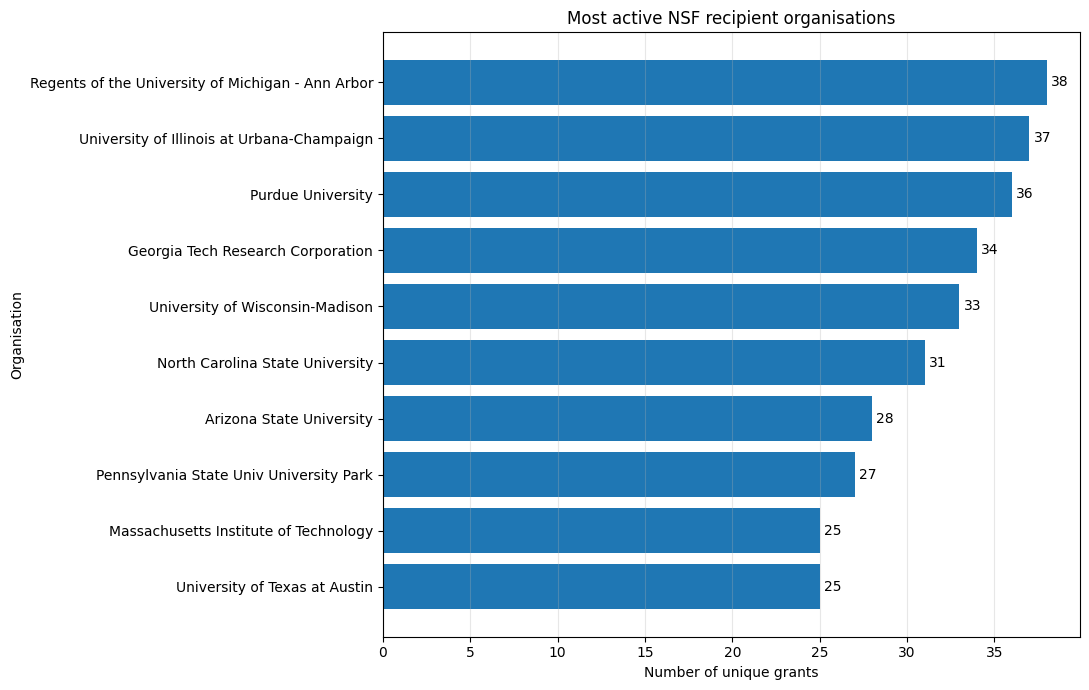

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\14_top_nsf_organisations.png


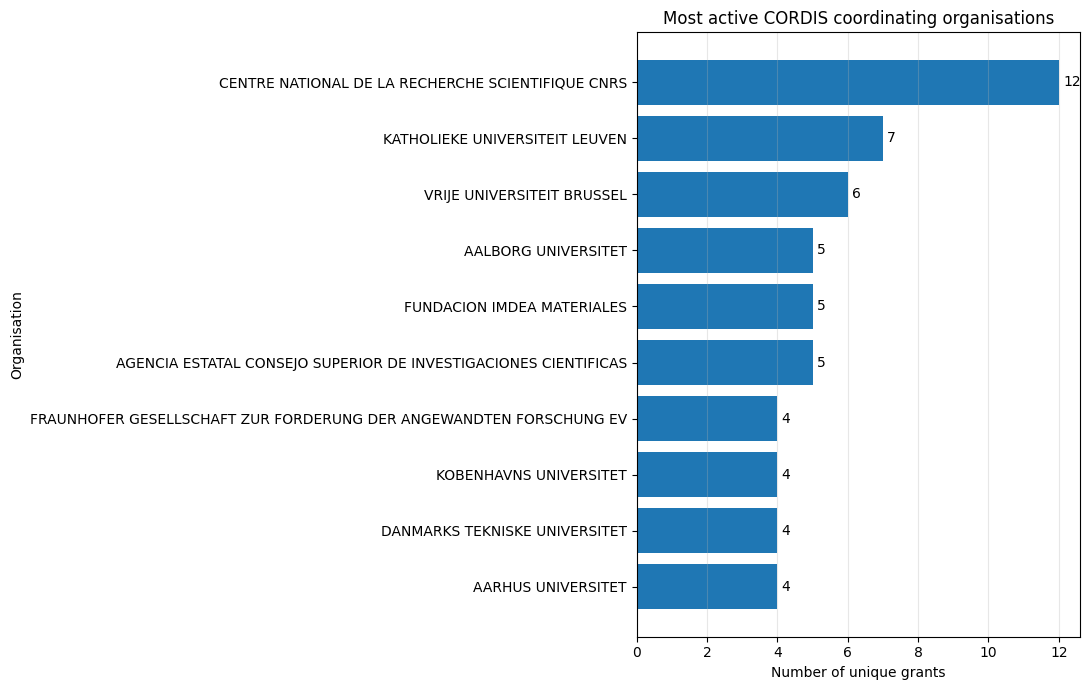

Figure saved to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Visualizations\15_top_cordis_organisations.png


In [19]:
# Identify the most active organisations within the eight named topics

organisation_analysis_df = named_topic_grants_all_years_df.copy()

# Clean organisation names
organisation_analysis_df["organisation_name_clean"] = (
    organisation_analysis_df["organisation_name"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .fillna("Organisation not reported")
)

# Summarize organisation activity separately by source
organisation_summary_df = (
    organisation_analysis_df.groupby(
        ["source", "organisation_name_clean"],
        as_index=False,
    )
    .agg(
        grant_count=("grant_key", "nunique"),
        topic_count=("primary_topic", "nunique"),
        first_award_year=("award_year", "min"),
        latest_award_year=("award_year", "max"),
        median_award_amount=("amount_native", "median"),
    )
)

organisation_summary_df["median_award_amount"] = (
    organisation_summary_df["median_award_amount"].round(0)
)

# Select the ten most active organisations from each source
top_organisations_by_source_df = (
    organisation_summary_df.sort_values(
        ["source", "grant_count", "organisation_name_clean"],
        ascending=[True, False, True],
    )
    .groupby("source", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_organisations_by_source_df)

# Create one chart for NSF and one for CORDIS
organisation_figure_settings = {
    "NSF": {
        "title": "Most active NSF recipient organisations",
        "filename": "14_top_nsf_organisations.png",
    },
    "CORDIS": {
        "title": "Most active CORDIS coordinating organisations",
        "filename": "15_top_cordis_organisations.png",
    },
}

for source, settings in organisation_figure_settings.items():

    source_plot_df = (
        top_organisations_by_source_df.loc[
            top_organisations_by_source_df["source"] == source
        ]
        .sort_values("grant_count", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(11, 7))

    ax.barh(
        source_plot_df["organisation_name_clean"],
        source_plot_df["grant_count"],
    )

    ax.set_title(settings["title"])
    ax.set_xlabel("Number of unique grants")
    ax.set_ylabel("Organisation")
    ax.grid(axis="x", alpha=0.3)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.0f",
            padding=3,
        )

    fig.tight_layout()

    figure_path = (
        VISUALIZATIONS_DIR
        / settings["filename"]
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Figure saved to: {figure_path.resolve()}")

### Interpretation: leading organisations by funding source

The organisation analysis highlights institutions that repeatedly appear as lead recipients or project coordinators within the eight named research topics.

Key observations:

- NSF activity is concentrated among large US research universities with broad coverage across several AI-enabled chemistry and materials topics.
- The University of Michigan is the most active NSF recipient in the dataset, with 38 grants across seven of the eight named topics.
- The University of Illinois Urbana-Champaign, Purdue University, Georgia Tech, and the University of Wisconsin–Madison also show sustained activity throughout 2021–2025.
- Several leading NSF organisations participate across four or more topics, suggesting broad institutional capability rather than narrow specialisation.
- CNRS is the most active CORDIS coordinating organisation, with 12 projects across three topics.
- KU Leuven, Vrije Universiteit Brussel, Aalborg University, CSIC, Fraunhofer, and several Danish universities also appear among the most active European coordinators.
- CORDIS coordinator counts are lower than NSF recipient counts, partly because the CORDIS dataset is smaller and represents lead coordinators rather than all consortium partners.
- Median award values vary considerably across organisations and should not be used as a direct measure of institutional performance.

These rankings represent recorded lead organisations only. NSF records identify the primary awardee, while CORDIS records identify the project coordinator. Collaborative partners are not fully represented in this comparison.

For GrantScopeAI, organisation information can help users identify institutions that are already active in a topic and provide context for similar funded projects. It should not be presented as a definitive ranking of research quality or total institutional activity.

In [20]:
# Create topic-specific programme and organisation intelligence tables

topic_detail_df = named_topic_grants_all_years_df.copy()

# Clean programme and organisation labels
topic_detail_df["programme_name_clean"] = (
    topic_detail_df["programme_name"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .fillna("Programme not reported")
)

topic_detail_df["organisation_name_clean"] = (
    topic_detail_df["organisation_name"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .fillna("Organisation not reported")
)

# Summarize programmes within each source and topic
topic_programme_summary_df = (
    topic_detail_df.groupby(
        [
            "primary_topic",
            "source",
            "currency",
            "programme_name_clean",
        ],
        as_index=False,
    )
    .agg(
        grant_count=("grant_key", "nunique"),
        median_award_amount=("amount_native", "median"),
        first_award_year=("award_year", "min"),
        latest_award_year=("award_year", "max"),
    )
)

topic_programme_summary_df["median_award_amount"] = (
    topic_programme_summary_df["median_award_amount"].round(0)
)

# Keep the ten most active programmes per topic and source
top_programmes_by_topic_df = (
    topic_programme_summary_df.sort_values(
        [
            "primary_topic",
            "source",
            "grant_count",
            "programme_name_clean",
        ],
        ascending=[True, True, False, True],
    )
    .groupby(
        ["primary_topic", "source"],
        group_keys=False,
    )
    .head(10)
    .reset_index(drop=True)
)

# Summarize organisations within each source and topic
topic_organisation_summary_df = (
    topic_detail_df.groupby(
        [
            "primary_topic",
            "source",
            "organisation_name_clean",
        ],
        as_index=False,
    )
    .agg(
        grant_count=("grant_key", "nunique"),
        median_award_amount=("amount_native", "median"),
        first_award_year=("award_year", "min"),
        latest_award_year=("award_year", "max"),
    )
)

topic_organisation_summary_df["median_award_amount"] = (
    topic_organisation_summary_df["median_award_amount"].round(0)
)

# Keep the ten most active organisations per topic and source
top_organisations_by_topic_df = (
    topic_organisation_summary_df.sort_values(
        [
            "primary_topic",
            "source",
            "grant_count",
            "organisation_name_clean",
        ],
        ascending=[True, True, False, True],
    )
    .groupby(
        ["primary_topic", "source"],
        group_keys=False,
    )
    .head(10)
    .reset_index(drop=True)
)

# Use AI-enabled catalysis as a demonstration topic
example_topic = "AI-enabled catalysis"

print(f"Example topic: {example_topic}")

print("\nMost active programmes:")
display(
    top_programmes_by_topic_df.loc[
        top_programmes_by_topic_df["primary_topic"]
        == example_topic,
        [
            "source",
            "currency",
            "programme_name_clean",
            "grant_count",
            "median_award_amount",
            "first_award_year",
            "latest_award_year",
        ],
    ]
)

print("\nMost active organisations:")
display(
    top_organisations_by_topic_df.loc[
        top_organisations_by_topic_df["primary_topic"]
        == example_topic,
        [
            "source",
            "organisation_name_clean",
            "grant_count",
            "median_award_amount",
            "first_award_year",
            "latest_award_year",
        ],
    ]
)

print(
    "\nTopic-programme rows:",
    len(top_programmes_by_topic_df),
)

print(
    "Topic-organisation rows:",
    len(top_organisations_by_topic_df),
)

Example topic: AI-enabled catalysis

Most active programmes:


,source,currency,programme_name_clean,grant_count,median_award_amount,first_award_year,latest_award_year
0,CORDIS,EUR,MSCA Postdoctoral Fellowships 2022,6,174035.0,2023,2024
1,CORDIS,EUR,ERC ADVANCED GRANTS,5,2500000.0,2023,2025
2,CORDIS,EUR,ERC STARTING GRANTS,5,1499643.0,2024,2025
3,CORDIS,EUR,MSCA Postdoctoral Fellowships 2021,5,183530.0,2022,2022
4,CORDIS,EUR,ERC CONSOLIDATOR GRANTS,4,1998050.0,2022,2025
5,CORDIS,EUR,ERA Fellowships,3,153487.0,2024,2025
6,CORDIS,EUR,MSCA Postdoctoral Fellowships 2023,3,181153.0,2024,2025
7,CORDIS,EUR,MSCA Postdoctoral Fellowships 2024,3,322164.0,2025,2025
8,CORDIS,EUR,ERC PROOF OF CONCEPT GRANTS2,2,150000.0,2023,2023
9,CORDIS,EUR,MSCA Doctoral Networks 2023,2,3306802.0,2025,2025



Most active organisations:


,source,organisation_name_clean,grant_count,median_award_amount,first_award_year,latest_award_year
0,CORDIS,KATHOLIEKE UNIVERSITEIT LEUVEN,3,3949949.0,2022,2025
1,CORDIS,UNIVERSITAT DE GIRONA,3,322164.0,2023,2025
2,CORDIS,FONDAZIONE ISTITUTO ITALIANO DI TECNOLOGIA,2,820075.0,2023,2024
3,CORDIS,FUNDACIO INSTITUT CATALA D'INVESTIGACIO QUIMICA,2,178381.0,2022,2024
4,CORDIS,POLITECNICO DI MILANO,2,4254022.0,2022,2023
5,CORDIS,TECHNISCHE UNIVERSITAET MUENCHEN,2,1742450.0,2022,2025
6,CORDIS,UNIVERSIDAD DEL PAIS VASCO/ EUSKAL HERRIKO UNIBERTSITATEA,2,3060139.0,2022,2023
7,CORDIS,AALBORG UNIVERSITET,1,5707393.0,2022,2022
8,CORDIS,AARHUS UNIVERSITET,1,196829.0,2023,2023
9,CORDIS,AGENCIA ESTATAL CONSEJO SUPERIOR DE INVESTIGACIONES CIENTIFICAS,1,4997125.0,2022,2022



Topic-programme rows: 116
Topic-organisation rows: 122


### Interpretation: AI-enabled catalysis funding ecosystem

AI-enabled catalysis provides a useful demonstration of how GrantScopeAI can connect a research topic with relevant funding programmes and active institutions.

Key observations:

- NSF support is concentrated in directly relevant scientific programmes, led by `Chemical Catalysis`, `Catalysis`, and `Chemical Theory, Models and Computational Methods`.
- DMREF also appears prominently, showing overlap between catalysis and data-driven materials research.
- Additional NSF support comes through research infrastructure, software, biochemical engineering, and institutional-capacity programmes.
- CORDIS support is distributed across researcher-development and investigator-led schemes, particularly MSCA Postdoctoral Fellowships and ERC grants.
- ERC Starting, Consolidator, and Advanced Grants indicate support across several researcher career stages.
- CORDIS median funding differs greatly by mechanism: fellowships are typically much smaller than ERC, doctoral-network, or collaborative projects.
- The University of Michigan and Rutgers are the most frequent NSF lead recipients in this topic, with eight awards each.
- The University of Chicago, Georgia Tech, Penn State, UCLA, and several other institutions also appear repeatedly.
- KU Leuven and the University of Girona are the most frequent CORDIS coordinators in the AI-enabled catalysis subset, although European organisation counts remain relatively small.
- The broad range of organisations suggests that AI-enabled catalysis is not concentrated within one institution or one funding mechanism.

These results demonstrate a potential Streamlit workflow: after identifying a user's research topic, GrantScopeAI could present the programmes that have supported similar work, active organisations, typical award values, and links to relevant funded projects.

Organisation rankings represent lead recipients or coordinators only and should not be interpreted as complete collaboration networks or measures of research quality.

A minor programme-label issue, such as `ERC PROOF OF CONCEPT GRANTS2`, should be normalized before producing the final dashboard or application export.

In [21]:
# Select candidate grants for the Streamlit demonstration
# and later similarity-model evaluation

demo_topic = "AI-enabled catalysis"

demo_research_concept = """
Machine-learning-guided discovery of stable heterogeneous catalysts
using automated experimentation and closed-loop optimisation.
"""

# Define transparent keywords for the initial manual shortlist
demo_keywords = [
    "machine learning",
    "artificial intelligence",
    "data-driven",
    "catalyst",
    "catalysis",
    "heterogeneous",
    "reaction",
    "automated",
    "automation",
    "closed-loop",
    "optimization",
    "optimisation",
    "discovery",
]

presentation_candidates_df = grants_df.loc[
    (grants_df["primary_topic"] == demo_topic)
    & (grants_df["relevance_tier"] == "core_match")
    & grants_df["title"].notna()
    & grants_df["abstract"].notna()
    & grants_df["source_url"].notna()
].copy()

# Combine title and abstract for transparent keyword screening
presentation_candidates_df["search_text"] = (
    presentation_candidates_df["title"].fillna("")
    + " "
    + presentation_candidates_df["abstract"].fillna("")
).str.lower()

# Record which demonstration keywords appear in each grant
presentation_candidates_df["demo_matched_keywords"] = (
    presentation_candidates_df["search_text"].apply(
        lambda text: [
            keyword
            for keyword in demo_keywords
            if keyword in text
        ]
    )
)

presentation_candidates_df["demo_keyword_count"] = (
    presentation_candidates_df["demo_matched_keywords"].str.len()
)

# Prefer grants with stronger keyword overlap, multiple topic matches,
# and more recent award years
presentation_candidates_df = (
    presentation_candidates_df.sort_values(
        [
            "source",
            "demo_keyword_count",
            "topic_match_count",
            "award_year",
        ],
        ascending=[True, False, False, False],
    )
)

# Select up to five examples from each funding source
presentation_example_grants_df = (
    presentation_candidates_df.groupby(
        "source",
        group_keys=False,
    )
    .head(5)
    .reset_index(drop=True)
)

# Create a compact abstract preview for notebook review
presentation_example_grants_df["abstract_preview"] = (
    presentation_example_grants_df["abstract"]
    .str.slice(0, 250)
    .str.rstrip()
    + "..."
)

display_columns = [
    "source",
    "grant_key",
    "title",
    "award_year",
    "programme_name",
    "organisation_name",
    "amount_native",
    "currency",
    "demo_keyword_count",
    "demo_matched_keywords",
    "abstract_preview",
    "source_url",
]

display(
    presentation_example_grants_df[display_columns]
)

print(
    "Selected demonstration grants:",
    len(presentation_example_grants_df),
)

print(
    "Source distribution:"
)

display(
    presentation_example_grants_df["source"]
    .value_counts()
    .rename_axis("source")
    .reset_index(name="grant_count")
)

print("\nPrepared demonstration concept:")
print(demo_research_concept.strip())

,source,grant_key,title,award_year,programme_name,organisation_name,amount_native,currency,demo_keyword_count,demo_matched_keywords,abstract_preview,source_url
0,CORDIS,CORDIS_101098001,"Automated, miniaturized and accelerated drug discovery: AMADEUS",2024,ERC ADVANCED GRANTS,UNIVERZITA PALACKEHO V OLOMOUCI,3409401.00,EUR,7,"[machine learning, artificial intelligence, catalysis, automated, automation, optimization, discovery]",The mantra ‘Automation + Miniaturization = Acceleration’ is successfully applied in many research areas and technolo...,https://cordis.europa.eu/project/id/101098001
1,CORDIS,CORDIS_101062692,Computationally driven discovery of organic dyes for photoredox catalysis from physicochemical principles and mechan...,2022,MSCA Postdoctoral Fellowships 2021,KATHOLIEKE UNIVERSITEIT LEUVEN,290444.16,EUR,7,"[machine learning, catalyst, catalysis, reaction, automated, optimization, discovery]",Photoredox catalysis has become a quintessential part of organic synthesis and gained wide interest in the chemical ...,https://cordis.europa.eu/project/id/101062692
2,CORDIS,CORDIS_101206634,Robot-mediated development of statistical models for mechanistic analysis amplification in synthetic organic reactions,2025,MSCA Postdoctoral Fellowships 2024,UNIVERSITAT DE GIRONA,322164.36,EUR,6,"[machine learning, catalyst, reaction, automated, optimization, discovery]",Cyb-org aims to apply well-established machine learning (ML) techniques to innovate mechanistic studies and optimiza...,https://cordis.europa.eu/project/id/101206634
3,CORDIS,CORDIS_101118768,Directed Evolution of Metastable Electrocatalyst Interfaces for Energy Conversion,2024,ERC Synergy Grants,KOBENHAVNS UNIVERSITET,9973679.00,EUR,5,"[machine learning, catalyst, catalysis, reaction, discovery]",It is our aim to transform the research field of electrocatalysis from the established “initial (as-synthesized) sta...,https://cordis.europa.eu/project/id/101118768
4,CORDIS,CORDIS_101204747,Development of Data-assisted Photo-Organocatalytic Transformations,2025,MSCA Postdoctoral Fellowships 2024,UNIVERSITA DEGLI STUDI DI PADOVA,396991.08,EUR,5,"[machine learning, catalyst, catalysis, reaction, discovery]",Photocatalysis is now a well-established method for developing sustainable protocols in synthetic organic chemistry....,https://cordis.europa.eu/project/id/101204747
5,NSF,NSF_2309852,Semi-Automated Discovery of Synthetic Polymers with Protein Features,2023,Cellular & Biochem Engineering,Rutgers University New Brunswick,579734.00,USD,8,"[machine learning, artificial intelligence, catalyst, reaction, automated, automation, closed-loop, discovery]","Enzymes are biological catalysts with unrivaled complexity. In some cases, tens of millions of years of evolution ha...",https://www.nsf.gov/awardsearch/showAward?AWD_ID=2309852
6,NSF,NSF_2554343,Collaborative Research: DMREF: Atomically precise catalyst design for selective bond activation,2025,"Catalysis, DMREF",University of Virginia Main Campus,625184.00,USD,7,"[machine learning, artificial intelligence, catalyst, catalysis, heterogeneous, reaction, discovery]",The project develops a design methodology for supported single-atom catalysts (SACs) – an emerging class of supporte...,https://www.nsf.gov/awardsearch/showAward?AWD_ID=2554343
7,NSF,NSF_2318141,CCI Phase I: NSF Center for Sustainable Photoredox Catalysis (SuPRCat),2023,Phase I Ctrs for Chem Innovati,Colorado State University,1800000.00,USD,7,"[machine learning, data-driven, catalyst, catalysis, heterogeneous, reaction, discovery]",The NSF Center for Sustainable Photoredox Catalysis (SuPRCat) is supported by the Centers for Chemical Innovation (C...,https://www.nsf.gov/awardsearch/showAward?AWD_ID=2318141
8,NSF,NSF_2323699,Collaborative Research: DMREF: Atomically precise catalyst design for selective bond activation,2023,"Catalysis, DMREF",Virginia Polytechnic Institute and State University,625184.00,USD,7,"[machine learning, artificial intelligence, catalyst, catalysi

Selected demonstration grants: 10
Source distribution:


,source,grant_count
0,CORDIS,5
1,NSF,5



Prepared demonstration concept:
Machine-learning-guided discovery of stable heterogeneous catalysts
using automated experimentation and closed-loop optimisation.


### Interpretation: initial demonstration-grant shortlist

The transparent keyword screen produced ten candidate projects for the proposed research concept:

Machine-learning-guided discovery of stable heterogeneous catalysts using automated experimentation and closed-loop optimisation.

Several projects appear strongly relevant:

- the computational discovery of photoredox catalysts;
- robot-mediated reaction-development and mechanistic modelling;
- data-assisted photocatalytic transformations;
- atomically precise catalyst design;
- semi-automated materials discovery;
- sustainable photoredox catalysis.

The shortlist also reveals limitations of simple keyword counting.

For example:

- the AMADEUS drug-discovery project contains strong automation and machine-learning terminology but may be less relevant to heterogeneous catalysis;
- repeated keyword mentions do not necessarily indicate stronger conceptual similarity;
- three NSF records describe the same collaborative atomically precise catalyst-design project at different participating institutions.

These collaborative awards are valid individual NSF records, but including all three in a small evaluation set would overrepresent one research concept.

Before using the shortlist as a benchmark, the projects should therefore be:

1. manually labelled for relevance;
2. checked for duplicated or closely related collaborative projects;
3. reduced to a diverse set covering automation, catalyst discovery, reaction optimisation, and data-driven experimentation.

This manually reviewed set will provide a more credible reference for evaluating the TF-IDF similarity model in Notebook 07.

In [22]:
# Create a manual relevance-review table for the demonstration shortlist

manual_review_df = presentation_example_grants_df[
    [
        "source",
        "grant_key",
        "title",
        "award_year",
        "programme_name",
        "organisation_name",
        "demo_keyword_count",
        "demo_matched_keywords",
        "source_url",
    ]
].copy()

# Fields to be completed during manual review
manual_review_df["manual_relevance_score"] = pd.Series(
    pd.NA,
    index=manual_review_df.index,
    dtype="Int64",
)

manual_review_df["manual_relevance_label"] = pd.NA
manual_review_df["related_project_group"] = pd.NA
manual_review_df["keep_as_representative"] = True
manual_review_df["review_notes"] = pd.NA

display(manual_review_df)

,source,grant_key,title,award_year,programme_name,organisation_name,demo_keyword_count,demo_matched_keywords,source_url,manual_relevance_score,manual_relevance_label,related_project_group,keep_as_representative,review_notes
0,CORDIS,CORDIS_101098001,"Automated, miniaturized and accelerated drug discovery: AMADEUS",2024,ERC ADVANCED GRANTS,UNIVERZITA PALACKEHO V OLOMOUCI,7,"[machine learning, artificial intelligence, catalysis, automated, automation, optimization, discovery]",https://cordis.europa.eu/project/id/101098001,<NA>,<NA>,<NA>,True,<NA>
1,CORDIS,CORDIS_101062692,Computationally driven discovery of organic dyes for photoredox catalysis from physicochemical principles and mechan...,2022,MSCA Postdoctoral Fellowships 2021,KATHOLIEKE UNIVERSITEIT LEUVEN,7,"[machine learning, catalyst, catalysis, reaction, automated, optimization, discovery]",https://cordis.europa.eu/project/id/101062692,<NA>,<NA>,<NA>,True,<NA>
2,CORDIS,CORDIS_101206634,Robot-mediated development of statistical models for mechanistic analysis amplification in synthetic organic reactions,2025,MSCA Postdoctoral Fellowships 2024,UNIVERSITAT DE GIRONA,6,"[machine learning, catalyst, reaction, automated, optimization, discovery]",https://cordis.europa.eu/project/id/101206634,<NA>,<NA>,<NA>,True,<NA>
3,CORDIS,CORDIS_101118768,Directed Evolution of Metastable Electrocatalyst Interfaces for Energy Conversion,2024,ERC Synergy Grants,KOBENHAVNS UNIVERSITET,5,"[machine learning, catalyst, catalysis, reaction, discovery]",https://cordis.europa.eu/project/id/101118768,<NA>,<NA>,<NA>,True,<NA>
4,CORDIS,CORDIS_101204747,Development of Data-assisted Photo-Organocatalytic Transformations,2025,MSCA Postdoctoral Fellowships 2024,UNIVERSITA DEGLI STUDI DI PADOVA,5,"[machine learning, catalyst, catalysis, reaction, discovery]",https://cordis.europa.eu/project/id/101204747,<NA>,<NA>,<NA>,True,<NA>
5,NSF,NSF_2309852,Semi-Automated Discovery of Synthetic Polymers with Protein Features,2023,Cellular & Biochem Engineering,Rutgers University New Brunswick,8,"[machine learning, artificial intelligence, catalyst, reaction, automated, automation, closed-loop, discovery]",https://www.nsf.gov/awardsearch/showAward?AWD_ID=2309852,<NA>,<NA>,<NA>,True,<NA>
6,NSF,NSF_2554343,Collaborative Research: DMREF: Atomically precise catalyst design for selective bond activation,2025,"Catalysis, DMREF",University of Virginia Main Campus,7,"[machine learning, artificial intelligence, catalyst, catalysis, heterogeneous, reaction, discovery]",https://www.nsf.gov/awardsearch/showAward?AWD_ID=2554343,<NA>,<NA>,<NA>,True,<NA>
7,NSF,NSF_2318141,CCI Phase I: NSF Center for Sustainable Photoredox Catalysis (SuPRCat),2023,Phase I Ctrs for Chem Innovati,Colorado State University,7,"[machine learning, data-driven, catalyst, catalysis, heterogeneous, reaction, discovery]",https://www.nsf.gov/awardsearch/showAward?AWD_ID=2318141,<NA>,<NA>,<NA>,True,<NA>
8,NSF,NSF_2323699,Collaborative Research: DMREF: Atomically precise catalyst design for selective bond activation,2023,"Catalysis, DMREF",Virginia Polytechnic Institute and State University,7,"[machine learning, artificial intelligence, catalyst, catalysis, heterogeneous, reaction, discovery]",https://www.nsf.gov/awardsearch/showAward?AWD_ID=2323699,<NA>,<NA>,<NA>,True,<NA>
9,NSF,NSF_2323700,Collaborative Research: DMREF: Atomically precise catalyst design for selective bond activation,2023,DMREF,University of Delaware,7,"[machine learning, artificial intelligence, catalyst, catalysis, heterogeneous, reaction, discovery]",https://www.nsf.gov/awardsearch/showAward?AWD_ID=2323700,<NA>,<NA>,<NA>,True,<NA>


In [23]:
# Populate the provisional manual relevance review

manual_review_decisions = {
    "CORDIS_101098001": {
        "score": 1,
        "label": "Weak match",
        "group": "AMADEUS",
        "keep": True,
        "notes": (
            "Strong automation and machine-learning overlap, but the main "
            "application is drug discovery rather than catalyst discovery."
        ),
    },
    "CORDIS_101062692": {
        "score": 2,
        "label": "Relevant",
        "group": "PHOTODYES",
        "keep": True,
        "notes": (
            "Computational and machine-learning-guided photoredox catalyst "
            "discovery, but limited evidence of closed-loop experimentation."
        ),
    },
    "CORDIS_101206634": {
        "score": 3,
        "label": "Strong match",
        "group": "CYB_ORG",
        "keep": True,
        "notes": (
            "Robot-mediated experimentation, machine learning, reaction "
            "optimisation, and mechanistic analysis closely match the concept."
        ),
    },
    "CORDIS_101118768": {
        "score": 2,
        "label": "Relevant",
        "group": "EVOLVE",
        "keep": True,
        "notes": (
            "Strong catalyst-design relevance and machine-learning content, "
            "but automation and closed-loop experimentation are less explicit."
        ),
    },
    "CORDIS_101204747": {
        "score": 2,
        "label": "Relevant",
        "group": "DATAPHOTO",
        "keep": True,
        "notes": (
            "Data-assisted photocatalytic reaction development is relevant, "
            "but the automation component appears limited."
        ),
    },
    "NSF_2309852": {
        "score": 2,
        "label": "Relevant",
        "group": "POLYMER_DISCOVERY",
        "keep": True,
        "notes": (
            "Strong semi-automated and closed-loop discovery workflow, although "
            "the scientific focus is synthetic polymers rather than catalysts."
        ),
    },
    "NSF_2554343": {
        "score": 3,
        "label": "Strong match",
        "group": "DMREF_ATOMIC_CATALYST",
        "keep": True,
        "notes": (
            "Machine-learning-guided heterogeneous catalyst design closely "
            "matches the scientific component of the proposed concept."
        ),
    },
    "NSF_2318141": {
        "score": 2,
        "label": "Relevant",
        "group": "SUPRCAT",
        "keep": True,
        "notes": (
            "Strong data-driven and sustainable catalysis relevance, but "
            "closed-loop automated experimentation is less explicit."
        ),
    },
    "NSF_2323699": {
        "score": 3,
        "label": "Strong match",
        "group": "DMREF_ATOMIC_CATALYST",
        "keep": False,
        "notes": (
            "Closely relevant, but represents the same collaborative research "
            "concept as the selected NSF_2554343 representative."
        ),
    },
    "NSF_2323700": {
        "score": 3,
        "label": "Strong match",
        "group": "DMREF_ATOMIC_CATALYST",
        "keep": False,
        "notes": (
            "Closely relevant, but represents the same collaborative research "
            "concept as the selected NSF_2554343 representative."
        ),
    },
}

for grant_key, decision in manual_review_decisions.items():
    row_mask = manual_review_df["grant_key"] == grant_key

    manual_review_df.loc[
        row_mask,
        "manual_relevance_score",
    ] = decision["score"]

    manual_review_df.loc[
        row_mask,
        "manual_relevance_label",
    ] = decision["label"]

    manual_review_df.loc[
        row_mask,
        "related_project_group",
    ] = decision["group"]

    manual_review_df.loc[
        row_mask,
        "keep_as_representative",
    ] = decision["keep"]

    manual_review_df.loc[
        row_mask,
        "review_notes",
    ] = decision["notes"]

# Create the diverse benchmark subset
evaluation_reference_df = manual_review_df.loc[
    manual_review_df["keep_as_representative"]
].copy()

display(
    manual_review_df[
        [
            "grant_key",
            "title",
            "manual_relevance_score",
            "manual_relevance_label",
            "related_project_group",
            "keep_as_representative",
            "review_notes",
        ]
    ]
)

print(
    "Reviewed candidates:",
    len(manual_review_df),
)

print(
    "Representative benchmark records:",
    len(evaluation_reference_df),
)

print(
    "Strong or relevant benchmark records:",
    (
        evaluation_reference_df["manual_relevance_score"] >= 2
    ).sum(),
)

,grant_key,title,manual_relevance_score,manual_relevance_label,related_project_group,keep_as_representative,review_notes
0,CORDIS_101098001,"Automated, miniaturized and accelerated drug discovery: AMADEUS",1,Weak match,AMADEUS,True,"Strong automation and machine-learning overlap, but the main application is drug discovery rather than catalyst disc..."
1,CORDIS_101062692,Computationally driven discovery of organic dyes for photoredox catalysis from physicochemical principles and mechan...,2,Relevant,PHOTODYES,True,"Computational and machine-learning-guided photoredox catalyst discovery, but limited evidence of closed-loop experim..."
2,CORDIS_101206634,Robot-mediated development of statistical models for mechanistic analysis amplification in synthetic organic reactions,3,Strong match,CYB_ORG,True,"Robot-mediated experimentation, machine learning, reaction optimisation, and mechanistic analysis closely match the ..."
3,CORDIS_101118768,Directed Evolution of Metastable Electrocatalyst Interfaces for Energy Conversion,2,Relevant,EVOLVE,True,"Strong catalyst-design relevance and machine-learning content, but automation and closed-loop experimentation are le..."
4,CORDIS_101204747,Development of Data-assisted Photo-Organocatalytic Transformations,2,Relevant,DATAPHOTO,True,"Data-assisted photocatalytic reaction development is relevant, but the automation component appears limited."
5,NSF_2309852,Semi-Automated Discovery of Synthetic Polymers with Protein Features,2,Relevant,POLYMER_DISCOVERY,True,"Strong semi-automated and closed-loop discovery workflow, although the scientific focus is synthetic polymers rather..."
6,NSF_2554343,Collaborative Research: DMREF: Atomically precise catalyst design for selective bond activation,3,Strong match,DMREF_ATOMIC_CATALYST,True,Machine-learning-guided heterogeneous catalyst design closely matches the scientific component of the proposed concept.
7,NSF_2318141,CCI Phase I: NSF Center for Sustainable Photoredox Catalysis (SuPRCat),2,Relevant,SUPRCAT,True,"Strong data-driven and sustainable catalysis relevance, but closed-loop automated experimentation is less explicit."
8,NSF_2323699,Collaborative Research: DMREF: Atomically precise catalyst design for selective bond activation,3,Strong match,DMREF_ATOMIC_CATALYST,False,"Closely relevant, but represents the same collaborative research concept as the selected NSF_2554343 representative."
9,NSF_2323700,Collaborative Research: DMREF: Atomically precise catalyst design for selective bond activation,3,Strong match,DMREF_ATOMIC_CATALYST,False,"Closely relevant, but represents the same collaborative research concept as the selected NSF_2554343 representative."


Reviewed candidates: 10
Representative benchmark records: 8
Strong or relevant benchmark records: 7


### Interpretation: manual evaluation benchmark

Ten shortlisted grants were manually reviewed for relevance to the demonstration concept.

- Eight representative projects were retained.
- Two duplicate collaborative NSF awards were excluded from the benchmark.
- Seven retained projects were rated relevant or strong.
- One weak match was kept to test whether the similarity model can distinguish context from keyword overlap.

This small benchmark will support qualitative evaluation of the TF-IDF model in Notebook 07.

In [24]:
# Create one dashboard-ready overview row for each named topic

# Total unique grants by primary topic
topic_total_counts_df = (
    grants_df.loc[
        grants_df["primary_topic"].isin(named_topics)
    ]
    .groupby("primary_topic", as_index=False)
    .agg(
        total_grants=("grant_key", "nunique"),
    )
    .rename(columns={"primary_topic": "topic"})
)

# Source-specific grant counts
topic_source_counts_df = (
    grants_df.loc[
        grants_df["primary_topic"].isin(named_topics)
    ]
    .groupby(
        ["primary_topic", "source"],
        as_index=False,
    )
    .agg(
        grant_count=("grant_key", "nunique"),
    )
    .pivot(
        index="primary_topic",
        columns="source",
        values="grant_count",
    )
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(
        columns={
            "primary_topic": "topic",
            "CORDIS": "cordis_grants",
            "NSF": "nsf_grants",
        }
    )
)

# Core and broad relevance counts
topic_relevance_counts_df = (
    grants_df.loc[
        grants_df["primary_topic"].isin(named_topics)
    ]
    .groupby(
        ["primary_topic", "relevance_tier"],
        as_index=False,
    )
    .agg(
        grant_count=("grant_key", "nunique"),
    )
    .pivot(
        index="primary_topic",
        columns="relevance_tier",
        values="grant_count",
    )
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(
        columns={
            "primary_topic": "topic",
            "core_match": "core_grants",
            "broad_match": "broad_grants",
        }
    )
)

# Add publication and recent funding indicators
topic_momentum_columns = [
    "topic",
    "grant_count_2022",
    "grant_count_2025",
    "grant_change_2022_2025",
    "grant_growth_2022_2025_pct",
    "publication_count_2022",
    "publication_count_2025",
    "publication_change_2022_2025",
    "publication_growth_2022_2025_pct",
]

topic_overview_df = (
    topic_total_counts_df
    .merge(
        topic_source_counts_df,
        on="topic",
        how="left",
        validate="one_to_one",
    )
    .merge(
        topic_relevance_counts_df,
        on="topic",
        how="left",
        validate="one_to_one",
    )
    .merge(
        funding_publication_comparison_df[
            topic_momentum_columns
        ],
        on="topic",
        how="left",
        validate="one_to_one",
    )
)

topic_overview_df["core_share_pct"] = (
    topic_overview_df["core_grants"]
    / topic_overview_df["total_grants"]
    * 100
).round(1)

topic_overview_df = (
    topic_overview_df.sort_values(
        "total_grants",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("Topic rows:", len(topic_overview_df))
print("Duplicate topics:", topic_overview_df["topic"].duplicated().sum())

display(topic_overview_df)

Topic rows: 8
Duplicate topics: 0


,topic,total_grants,cordis_grants,nsf_grants,broad_grants,core_grants,grant_count_2022,grant_count_2025,grant_change_2022_2025,grant_growth_2022_2025_pct,publication_count_2022,publication_count_2025,publication_change_2022_2025,publication_growth_2022_2025_pct,core_share_pct
0,AI-enabled materials,913,118,795,140,773,152,227,75,49.3,146376,386893,240517,164.3,84.7
1,AI-enabled chemistry,803,138,665,124,679,153,207,54,35.3,54337,142246,87909,161.8,84.6
2,AI-enabled catalysis,343,70,273,22,321,63,88,25,39.7,8449,39893,31444,372.2,93.6
3,Materials informatics,122,2,120,12,110,19,13,-6,-31.6,511,1021,510,99.8,90.2
4,Cheminformatics,23,9,14,5,18,4,7,3,75.0,2997,4975,1978,66.0,78.3
5,Autonomous laboratories,14,1,13,4,10,2,6,4,200.0,119,859,740,621.8,71.4
6,Reaction prediction,12,3,9,1,11,5,3,-2,-40.0,256,576,320,125.0,91.7
7,Molecular machine learning,9,0,9,4,5,0,4,4,NaN,263,549,286,108.7,55.6


### Topic overview summary

The final topic overview separates established scale from emerging momentum.

- AI-enabled materials and chemistry have the largest funding and publication footprints.
- AI-enabled catalysis combines strong publication growth with meaningful grant activity.
- Autonomous laboratories has the fastest publication growth but remains small in absolute funding volume.
- Materials informatics and reaction prediction show publication growth alongside lower recent grant activity.

This table will support the Tableau overview and Streamlit topic explorer.

## 5. Export analytical outputs

The final EDA tables will be exported in compact, reusable formats for:

- Tableau dashboard development;
- Streamlit topic exploration;
- similarity-model evaluation;
- presentation examples.

Each output will be reloaded and validated after export.

In [25]:
# Export compact EDA tables for Tableau, Streamlit, and model evaluation

EDA_OUTPUT_DIR = Path("../Data/Processed_Data/EDA")
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Create compact presentation-example export
presentation_examples_export_df = (
    presentation_example_grants_df[
        [
            "source",
            "grant_key",
            "title",
            "abstract",
            "award_year",
            "programme_name",
            "organisation_name",
            "amount_native",
            "currency",
            "primary_topic",
            "demo_keyword_count",
            "demo_matched_keywords",
            "source_url",
        ]
    ]
    .copy()
)

# Define the EDA outputs
eda_outputs = {
    "topic_overview_2021_2025.csv": topic_overview_df,
    "annual_named_topic_grant_activity.csv": (
        annual_topic_grants_complete_df
    ),
    "funding_publication_comparison.csv": (
        funding_publication_comparison_df
    ),
    "top_programmes_by_source.csv": top_programmes_by_source_df,
    "top_organisations_by_source.csv": top_organisations_by_source_df,
    "top_programmes_by_topic.csv": top_programmes_by_topic_df,
    "top_organisations_by_topic.csv": top_organisations_by_topic_df,
    "presentation_example_grants.csv": presentation_examples_export_df,
    "manual_similarity_evaluation_reference.csv": evaluation_reference_df,
}

# Export each table
export_summary = []

for filename, dataframe in eda_outputs.items():

    output_path = EDA_OUTPUT_DIR / filename

    dataframe.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig",
    )

    export_summary.append(
        {
            "file": filename,
            "rows": len(dataframe),
            "columns": dataframe.shape[1],
            "path": str(output_path),
        }
    )

export_summary_df = pd.DataFrame(export_summary)

display(export_summary_df)

print(
    f"Exported {len(export_summary_df)} EDA files to: "
    f"{EDA_OUTPUT_DIR.resolve()}"
)

,file,rows,columns,path
0,topic_overview_2021_2025.csv,8,15,..\Data\Processed_Data\EDA\topic_overview_2021_2025.csv
1,annual_named_topic_grant_activity.csv,32,3,..\Data\Processed_Data\EDA\annual_named_topic_grant_activity.csv
2,funding_publication_comparison.csv,8,9,..\Data\Processed_Data\EDA\funding_publication_comparison.csv
3,top_programmes_by_source.csv,20,8,..\Data\Processed_Data\EDA\top_programmes_by_source.csv
4,top_organisations_by_source.csv,20,7,..\Data\Processed_Data\EDA\top_organisations_by_source.csv
5,top_programmes_by_topic.csv,116,8,..\Data\Processed_Data\EDA\top_programmes_by_topic.csv
6,top_organisations_by_topic.csv,122,7,..\Data\Processed_Data\EDA\top_organisations_by_topic.csv
7,presentation_example_grants.csv,10,13,..\Data\Processed_Data\EDA\presentation_example_grants.csv
8,manual_similarity_evaluation_reference.csv,8,14,..\Data\Processed_Data\EDA\manual_similarity_evaluation_reference.csv


Exported 9 EDA files to: C:\Users\kahau\OneDrive\Documents\Techmeup\Final_Project\GrantScopeAI\Data\Processed_Data\EDA


In [26]:
# Reload exported EDA files and verify their saved structure

reloaded_eda_outputs = {}

verification_rows = []

for filename, original_df in eda_outputs.items():

    file_path = EDA_OUTPUT_DIR / filename

    reloaded_df = pd.read_csv(
        file_path,
        low_memory=False,
    )

    reloaded_eda_outputs[filename] = reloaded_df

    verification_rows.append(
        {
            "file": filename,
            "expected_rows": len(original_df),
            "actual_rows": len(reloaded_df),
            "expected_columns": original_df.shape[1],
            "actual_columns": reloaded_df.shape[1],
            "shape_matches": (
                original_df.shape == reloaded_df.shape
            ),
        }
    )

eda_export_verification_df = pd.DataFrame(
    verification_rows
)

display(eda_export_verification_df)

print(
    "Files verified:",
    eda_export_verification_df["shape_matches"].sum(),
    "/",
    len(eda_export_verification_df),
)

# Confirm uniqueness in the most important analytical exports
print(
    "Duplicate topic rows:",
    reloaded_eda_outputs[
        "topic_overview_2021_2025.csv"
    ]["topic"].duplicated().sum(),
)

print(
    "Duplicate topic-year grant rows:",
    reloaded_eda_outputs[
        "annual_named_topic_grant_activity.csv"
    ].duplicated(
        subset=["topic", "year"]
    ).sum(),
)

print(
    "Duplicate funding-publication topics:",
    reloaded_eda_outputs[
        "funding_publication_comparison.csv"
    ]["topic"].duplicated().sum(),
)

print(
    "Duplicate evaluation grant keys:",
    reloaded_eda_outputs[
        "manual_similarity_evaluation_reference.csv"
    ]["grant_key"].duplicated().sum(),
)

,file,expected_rows,actual_rows,expected_columns,actual_columns,shape_matches
0,topic_overview_2021_2025.csv,8,8,15,15,True
1,annual_named_topic_grant_activity.csv,32,32,3,3,True
2,funding_publication_comparison.csv,8,8,9,9,True
3,top_programmes_by_source.csv,20,20,8,8,True
4,top_organisations_by_source.csv,20,20,7,7,True
5,top_programmes_by_topic.csv,116,116,8,8,True
6,top_organisations_by_topic.csv,122,122,7,7,True
7,presentation_example_grants.csv,10,10,13,13,True
8,manual_similarity_evaluation_reference.csv,8,8,14,14,True


Files verified: 9 / 9
Duplicate topic rows: 0
Duplicate topic-year grant rows: 0
Duplicate funding-publication topics: 0
Duplicate evaluation grant keys: 0


## EDA summary

The exploratory analysis identified several clear patterns:

- NSF contributes most funding records, while CORDIS projects generally have larger median native award values.
- AI-enabled materials and chemistry have the largest funding and publication footprints.
- AI-enabled catalysis combines strong publication growth with substantial grant activity.
- Autonomous laboratories shows the fastest publication growth but remains small in absolute funding volume.
- Materials informatics and reaction prediction show publication growth alongside lower recent grant activity.
- Programme and organisation patterns differ substantially between NSF and CORDIS.

Nine validated EDA outputs were exported for Tableau, Streamlit, and similarity-model development.

The next step is to build the explainable project-similarity model in Notebook 07.